# Setup

This notebook was developed in Google Colab with data stored in Google Drive.
All file paths use the base directory `/content/drive/MyDrive/Thesis/`.
To run this notebook, mount your Google Drive and update the base path below
to match your own folder structure.

In [29]:
# Update this path to match your Google Drive folder structure
BASE_DIR = "/content/drive/MyDrive/Thesis/"

# Set Up Cell 1 (Primary & Longitudinal)

In [30]:
# Set up cell 1
!pip install yt-dlp open_clip_torch umap-learn plotly tqdm isodate -q
!pip install kaleido==0.2.1
!apt-get install -y ffmpeg -q

from google.colab import drive
drive.mount('/content/drive')

import os, glob, requests, torch, open_clip, umap, plotly.express as px
import numpy as np, pandas as pd, subprocess, isodate, base64, io
from PIL import Image
from tqdm import tqdm

# df = pd.read_csv("/content/drive/MyDrive/Thesis/final_dataset.csv")
# all_ids_before_filter = set(df["videoId"].astype(str))  # save ALL ids before any filtering
# print(f"Loaded {len(df)} videos")

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preprocessing Steps

All these preprocessing and control steps are commented out so they do not have to run every time.

In [31]:
# df = pd.read_csv("/content/drive/MyDrive/Thesis/final_dataset.csv")

# # Remove duplicate title+channel combos, keep highest view count
# # df = df.sort_values("viewCount", ascending=False)
# df = df.drop_duplicates(subset=["channelTitle", "videoTitle"], keep="first")

# print(f"After deduplication: {len(df)} videos")
# print(df["outlet_category"].value_counts())

# df.to_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv", index=False)

In [32]:
# df = pd.read_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv")
# df["publishedAt"] = pd.to_datetime(df["publishedAt"], utc=True)
# df = df[df["publishedAt"] >= "2025-01-01"]
# print(f"Videos from 2025 onwards: {len(df)}")
# print(df["outlet_category"].value_counts())
# df.to_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv", index=False)

In [33]:
# kept_ids = set(df["videoId"].astype(str))  # df is now already filtered
# excluded_ids = all_ids_before_filter - kept_ids

# print(f"Removing files for {len(excluded_ids)} excluded videos...")

# import shutil
# for vid in excluded_ids:
#     thumb = f"/content/drive/MyDrive/Thesis/thesis_thumbnails/{vid}.jpg"
#     if os.path.exists(thumb):
#         os.remove(thumb)
#         print(f"Deleted thumbnail: {vid}")
#     frame_dir = f"/content/drive/MyDrive/Thesis/thesis_frames/{vid}"
#     if os.path.exists(frame_dir):
#         shutil.rmtree(frame_dir)
#         print(f"Deleted frames: {vid}")

# print(f"Cleanup done. Kept {len(kept_ids)} videos.")

Save all thumbnails.

In [34]:
# save_dir = "/content/drive/MyDrive/Thesis/thesis_thumbnails"
# os.makedirs(save_dir, exist_ok=True)

# for _, row in tqdm(df.iterrows(), total=len(df)):
#     vid = row["videoId"]
#     url = row["thumbnail_maxres"]
#     out = f"{save_dir}/{vid}.jpg"
#     if os.path.exists(out):
#         continue
#     try:
#         r = requests.get(url, timeout=10)
#         with open(out, "wb") as f:
#             f.write(r.content)
#     except:
#         print(f"Failed: {vid}")

Save frames every 10 seconds.

In [35]:
# frames_dir = "/content/drive/MyDrive/Thesis/thesis_frames"
# os.makedirs(frames_dir, exist_ok=True)
# skipped, processed, failed = 0, 0, 0

# for vid in tqdm(df["videoId"]):
#     out_dir = f"{frames_dir}/{vid}"
#     if os.path.exists(out_dir) and len(glob.glob(f"{out_dir}/*.jpg")) > 0:
#         skipped += 1
#         continue
#     os.makedirs(out_dir, exist_ok=True)
#     url = f"https://www.youtube.com/watch?v={vid}"
#     cmd = (
#         f'yt-dlp -f "bestvideo[height<=480][ext=mp4]" -o - "{url}" 2>/dev/null | '
#         f'ffmpeg -i pipe:0 -vf fps=1/10 "{out_dir}/frame_%04d.jpg" '
#         f'-hide_banner -loglevel error'
#     )
#     result = subprocess.run(cmd, shell=True)
#     if result.returncode != 0:
#         print(f"Failed: {vid}")
#         failed += 1
#     else:
#         processed += 1

# print(f"Skipped: {skipped} | Processed: {processed} | Failed: {failed}")

Control steps to check number of frames.

In [36]:
# frame_folders = glob.glob("/content/drive/MyDrive/Thesis/thesis_frames/*/")
# frame_ids = set([os.path.basename(f.rstrip("/")) for f in frame_folders])
# dataset_ids = set(df["videoId"].astype(str))

# extra = frame_ids - dataset_ids
# missing = dataset_ids - frame_ids

# print(f"Frame folders not in dataset: {len(extra)}")
# for v in extra:
#     print(f"  {v}")

# print(f"\nDataset videos with no frame folder: {len(missing)}")
# for v in missing:
#     print(f"  {v}")

In [37]:
# import shutil
# for vid in extra:
#     folder = f"/content/drive/MyDrive/Thesis/thesis_frames/{vid}"
#     shutil.rmtree(folder)
#     print(f"Deleted: {vid}")

In [38]:
# import glob, os

# frame_folders = glob.glob("/content/drive/MyDrive/Thesis/thesis_frames/*/")
# total_frames = 0
# frame_counts = []

# for folder in frame_folders:
#     frames = glob.glob(f"{folder}*.jpg")
#     count = len(frames)
#     total_frames += count
#     frame_counts.append(count)

# import numpy as np
# print(f"Total videos with frames: {len(frame_folders)}")
# print(f"Total frames: {total_frames}")
# print(f"Average frames per video: {np.mean(frame_counts):.1f}")
# print(f"Median frames per video: {np.median(frame_counts):.1f}")
# print(f"Average video length (minutes): {np.mean(frame_counts) * 10 / 60:.1f}")
# print(f"Min frames: {min(frame_counts)}, Max frames: {max(frame_counts)}")

In [39]:
# median_minutes = np.median(frame_counts) * 10 / 60
# mean_minutes = np.mean(frame_counts) * 10 / 60
# print(f"Mean: {mean_minutes:.1f} minutes")
# print(f"Median: {median_minutes:.1f} minutes")

# Set Up Cell 2 (Primary & Longitudinal)

This is the file path to the cleaned dataset with 153 entries. Use this cell (alongside set up cell 1) for all further analyses.

In [40]:
# Set up cell 2
df = pd.read_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv")
print(f"Loaded {len(df)} videos")
print(df["outlet_category"].value_counts())

Loaded 153 videos
outlet_category
western_legacy    93
indian_hybrid     26
independent       24
latin_american    10
Name: count, dtype: int64



# Transcript Analysis (Primary Corpus)

In [41]:
transcripts_dir = "/content/drive/MyDrive/Thesis/thesis_transcripts"
os.makedirs(transcripts_dir, exist_ok=True)

for vid in tqdm(df["videoId"]):
    out = f"{transcripts_dir}/{vid}.en.vtt"

    if os.path.exists(out):
        continue

    url = f"https://www.youtube.com/watch?v={vid}"

    cmd = (
        f'yt-dlp --write-auto-sub --sub-lang en --sub-format vtt '
        f'--skip-download -o "{transcripts_dir}/{vid}" "{url}" 2>/dev/null'
    )

    subprocess.run(cmd, shell=True)

100%|██████████| 153/153 [01:32<00:00,  1.65it/s]


In [42]:
import os
from collections import Counter

files = [f for f in os.listdir(transcripts_dir) if f.endswith(".vtt")]

base_ids = [f.replace(".en.vtt", "").replace(".vtt", "") for f in files]
counts = Counter(base_ids)

duplicates = {vid: count for vid, count in counts.items() if count > 1}

print("Total VTT files:", len(files))
print("Duplicate video IDs:", duplicates)

Total VTT files: 115
Duplicate video IDs: {}


Double-check how many videos have a transcript downloaded:

Some videos are missing, attributable to either unavailable auto-generated captions, the video being in a language other than English, or a failed download.


In [43]:
import glob
transcript_files = glob.glob("/content/drive/MyDrive/Thesis/thesis_transcripts/*.vtt")
print(f"Transcripts downloaded: {len(transcript_files)}")

# Check which videos are missing transcripts
transcript_ids = set([os.path.basename(f).replace(".en.vtt","").replace(".vtt","") for f in transcript_files])
dataset_ids = set(df["videoId"].astype(str))
missing = dataset_ids - transcript_ids
print(f"Videos without transcripts: {len(missing)}")

Transcripts downloaded: 115
Videos without transcripts: 38


# Visual Feature Extraction (Primary)

In [44]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
device = next(model.parameters()).device

thumbnail_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_thumbnails/*.jpg")
frame_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_frames/**/*.jpg", recursive=True)

print(f"Thumbnails found: {len(thumbnail_paths)}")
print(f"Frames found: {len(frame_paths)}")

all_paths = thumbnail_paths + frame_paths
labels = ["thumbnail"] * len(thumbnail_paths) + ["frame"] * len(frame_paths)
video_ids = (
    [os.path.basename(p).replace(".jpg","") for p in thumbnail_paths] +
    [os.path.basename(os.path.dirname(p)) for p in frame_paths]
)

# Resume logic: load any previously saved progress ---
progress_file = "/content/drive/MyDrive/Thesis/embeddings_progress.npy"
progress_meta = "/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv"

if os.path.exists(progress_file) and os.path.exists(progress_meta):
    saved_embeddings = np.load(progress_file).tolist()
    saved_meta = pd.read_csv(progress_meta)
    saved_paths = set(saved_meta["path"].tolist())
    print(f"Resuming — {len(saved_embeddings)} embeddings already done")
else:
    saved_embeddings = []
    saved_paths = set()
    print("Starting fresh")

embeddings, valid_paths, valid_labels, valid_ids = [], [], [], []

# Add already-saved ones first
if len(saved_embeddings) > 0:
    embeddings = saved_embeddings
    valid_paths = saved_meta["path"].tolist()
    valid_labels = saved_meta["label"].tolist()
    valid_ids = saved_meta["videoId"].tolist()

# Process remaining: save every 500 images
save_every = 500
new_since_save = 0

for p, label, vid in tqdm(zip(all_paths, labels, video_ids), total=len(all_paths)):
    if p in saved_paths:
        continue
    try:
        img = preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model.encode_image(img).squeeze().cpu().numpy()
        embeddings.append(emb)
        valid_paths.append(p)
        valid_labels.append(label)
        valid_ids.append(vid)
        new_since_save += 1

        # Save progress every 500 images
        if new_since_save >= save_every:
            np.save(progress_file, np.array(embeddings))
            meta = pd.DataFrame({"path": valid_paths, "label": valid_labels, "videoId": valid_ids})
            meta.to_csv(progress_meta, index=False)
            new_since_save = 0
            print(f"Progress saved: {len(embeddings)} embeddings")
    except:
        print(f"Failed: {p}")

# Final save
embeddings = np.array(embeddings)
np.save("/content/drive/MyDrive/Thesis/embeddings.npy", embeddings)
meta = pd.DataFrame({"path": valid_paths, "label": valid_labels, "videoId": valid_ids})
meta.to_csv(progress_meta, index=False)
print(f"Done! Total embeddings: {len(embeddings)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning:

QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).



Thumbnails found: 153
Frames found: 30110
Resuming — 30000 embeddings already done


100%|██████████| 30263/30263 [00:00<00:00, 342890.47it/s]


Done! Total embeddings: 30000


# Dimensionality Reduction and Spatial Visualisation

Compute one representative frame per video. Only include pairs in subsequent analysis involving representative frames.

In [45]:
df = pd.read_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv")

# Load embeddings and meta
embeddings = np.load("/content/drive/MyDrive/Thesis/embeddings.npy")
meta = pd.read_csv("/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv")

# Ensure meta dataframe has the same number of rows as embeddings to prevent indexing errors
if len(meta) > len(embeddings):
    meta = meta.iloc[:len(embeddings)]
elif len(embeddings) > len(meta):

    raise ValueError("Embeddings array has more entries than meta dataframe, indicating data inconsistency.")

valid_paths = meta["path"].tolist()
valid_labels = meta["label"].tolist()
valid_ids = meta["videoId"].tolist()

# Separate thumbnails and frames
thumb_mask = np.array(valid_labels) == "thumbnail"
frame_mask = np.array(valid_labels) == "frame"

thumb_embeddings = embeddings[thumb_mask]
thumb_paths_arr = np.array(valid_paths)[thumb_mask]
thumb_ids_arr = np.array(valid_ids)[thumb_mask]

frame_embeddings = embeddings[frame_mask]
frame_paths_arr = np.array(valid_paths)[frame_mask]
frame_ids_arr = np.array(valid_ids)[frame_mask]

# Select representative frame per video
representative_embeddings = []
representative_paths = []
representative_ids = []

for vid in tqdm(df["videoId"].astype(str)):
    mask = frame_ids_arr == vid
    if mask.sum() == 0:
        continue
    vid_frame_embs = frame_embeddings[mask]
    vid_frame_paths = frame_paths_arr[mask]
    mean_emb = vid_frame_embs.mean(axis=0)
    distances = np.linalg.norm(vid_frame_embs - mean_emb, axis=1)
    closest_idx = distances.argmin()
    representative_embeddings.append(vid_frame_embs[closest_idx])
    representative_paths.append(vid_frame_paths[closest_idx])
    representative_ids.append(vid)

representative_embeddings = np.array(representative_embeddings)
print(f"Representative frames selected: {len(representative_embeddings)}")

# Keep only thumbnails that have a representative frame
paired_ids = set(representative_ids)

thumb_keep_mask = np.array([vid in paired_ids for vid in thumb_ids_arr])

thumb_embeddings_clean = thumb_embeddings[thumb_keep_mask]
thumb_paths_clean = thumb_paths_arr[thumb_keep_mask]
thumb_ids_clean = thumb_ids_arr[thumb_keep_mask]

# Combine cleaned thumbnails + representative frames
combined_embeddings = np.concatenate([thumb_embeddings_clean, representative_embeddings])
combined_paths = list(thumb_paths_clean) + representative_paths
combined_ids = list(thumb_ids_clean) + representative_ids
combined_labels = ["thumbnail"] * len(thumb_embeddings_clean) + ["frame"] * len(representative_embeddings)

print("Clean thumbnails:", len(thumb_embeddings_clean))
print("Representative frames:", len(representative_embeddings))
print("Total for UMAP:", len(combined_embeddings))

# Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords = reducer.fit_transform(combined_embeddings)

master_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "videoId": combined_ids,
    "type": combined_labels,
    "path": combined_paths
})
master_df = master_df.merge(
    df[["videoId", "publishedAt", "channelTitle", "outlet_category"]],
    on="videoId", how="left"
)
master_df.to_csv("/content/drive/MyDrive/Thesis/thesis_embeddings.csv", index=False)
print(f"Master dataframe saved: {len(master_df)} rows")

100%|██████████| 153/153 [00:00<00:00, 805.79it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Representative frames selected: 150
Clean thumbnails: 150
Representative frames: 150
Total for UMAP: 300
Master dataframe saved: 300 rows


Visualization 1/4: thumbnails only.

In [46]:
!pip install kaleido==0.2.1

category_labels = {
    "western_legacy": "Western Legacy",
    "indian_hybrid": "Indian and Asian Platform-Hybrid",
    "latin_american": "Latin American",
    "independent": "Independent and Commentary"
}

thumb_df = master_df[master_df["type"] == "thumbnail"].copy()
thumb_df["Outlet Category"] = thumb_df["outlet_category"].map(category_labels)

fig = px.scatter(
    thumb_df, x="x", y="y",
    color="Outlet Category",
    hover_data=["channelTitle", "videoId"],
    title="Thumbnail Visual Space by Outlet Category",
    width=1100, height=750
)
fig.write_html("/content/drive/MyDrive/Thesis/plot_thumbnails.html")
fig.write_image("/content/drive/MyDrive/Thesis/plot_thumbnails.png", width=1400, height=900, scale=2)
fig.show()

The four thumbnails clustered together as identified in section 1.1.

VideoId: CN96t9fwN64


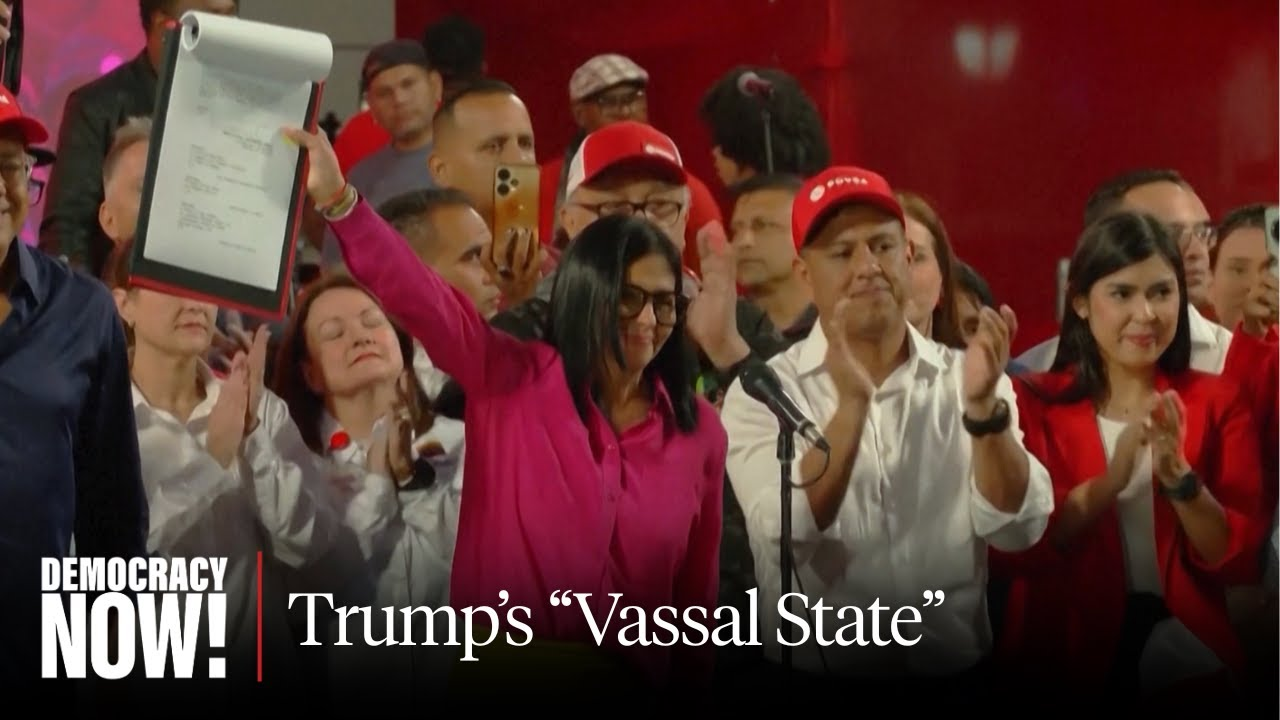

VideoId: 9a-yxY14Qso


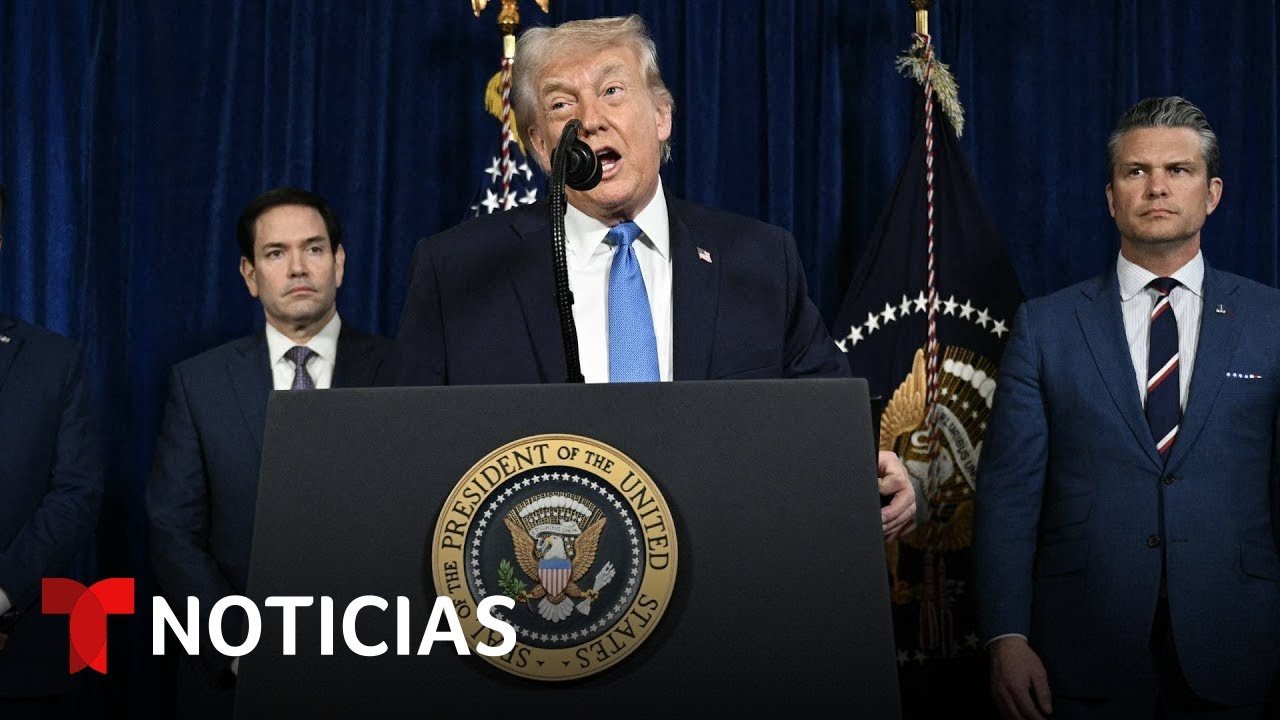

Not found: KRRruHNWyyl
VideoId: DJ0U6wD1ZG0


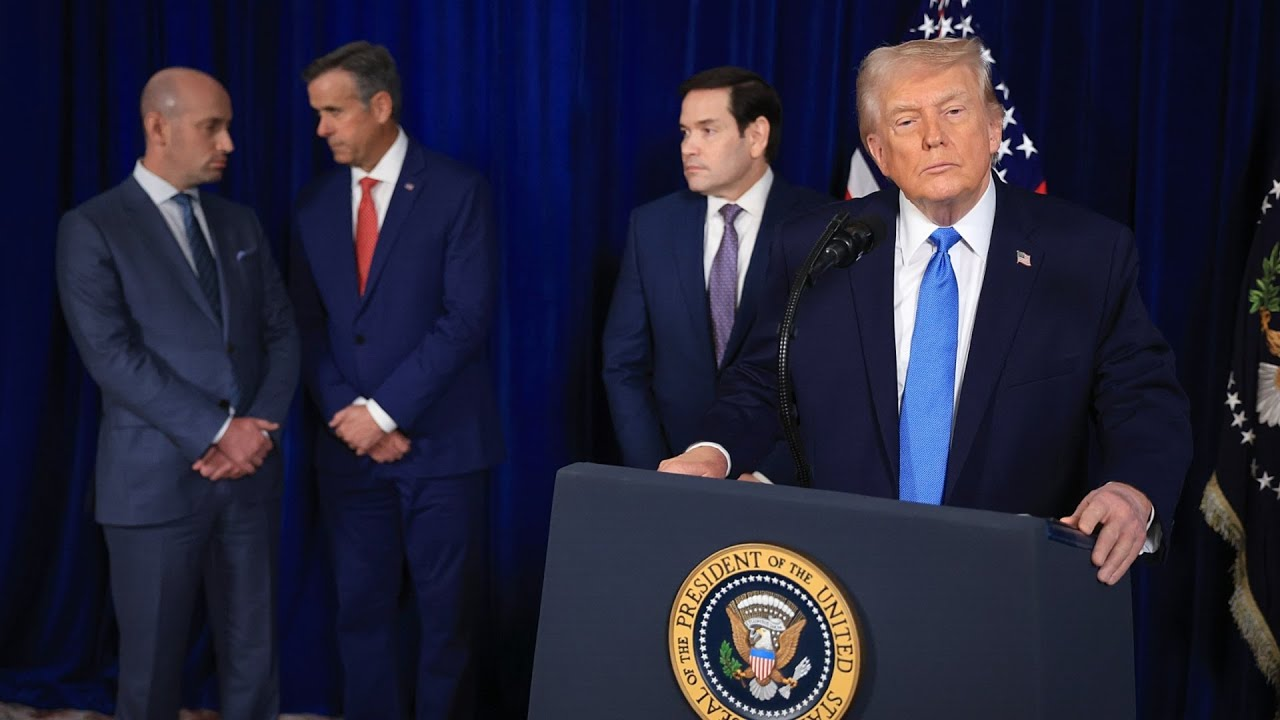

In [47]:
import os
import shutil
from IPython.display import display, Image as IPImage
import pandas as pd

cluster_ids = ['CN96t9fwN64', '9a-yxY14Qso', 'KRRruHNWyyl', 'DJ0U6wD1ZG0']

thumb_dir = '/content/drive/MyDrive/Thesis/thesis_thumbnails'

for vid in cluster_ids:
    path = f"{thumb_dir}/{vid}.jpg"
    if os.path.exists(path):
        print(f"VideoId: {vid}")
        display(IPImage(filename=path, width=300))
    else:
        print(f"Not found: {vid}")

Visualization 2/4: representative frames only.

In [48]:
frame_df = master_df[master_df["type"] == "frame"].copy()
frame_df["Outlet Category"] = frame_df["outlet_category"].map(category_labels)

fig = px.scatter(
    frame_df, x="x", y="y",
    color="Outlet Category",
    hover_data=["channelTitle", "videoId"],
    title="Representative Frame Visual Space by Outlet Category",
    width=1100, height=750
)
fig.write_html("/content/drive/MyDrive/Thesis/plot_frames.html")
fig.write_image("/content/drive/MyDrive/Thesis/plot_frames.png", width=1400, height=900, scale=2)
fig.show()

In [49]:
# # Check which thumbnails failed to convert to base64
# failed_thumbs = []
# for _, row in thumb_df.iterrows():
#     if row["b64"] is None:
#         failed_thumbs.append(row["videoId"])
#     else:
#         # Check if file exists and has content
#         path = row["path"]
#         if not os.path.exists(path) or os.path.getsize(path) < 1000:
#             failed_thumbs.append(row["videoId"])

# print(f"Problematic thumbnails: {failed_thumbs}")

In [50]:
# save_dir = "/content/drive/MyDrive/Thesis/thesis_thumbnails"

# for vid in failed_thumbs:
#     row = df[df["videoId"] == vid].iloc[0]
#     url = row["thumbnail_maxres"]
#     out = f"{save_dir}/{vid}.jpg"
#     try:
#         r = requests.get(url, timeout=10)
#         if len(r.content) > 1000:  # make sure it's a real image
#             with open(out, "wb") as f:
#                 f.write(r.content)
#             print(f"Re-downloaded: {vid}")
#         else:
#             print(f"URL returned empty response: {vid}")
#     except:
#         print(f"Failed again: {vid}")

Visualization 3/4: thumbnails and representative frames combined, both plotted as dots.

In [51]:
import plotly.graph_objects as go

thumb_df = master_df[master_df["type"] == "thumbnail"].copy()
thumb_df["publishedAt"] = pd.to_datetime(thumb_df["publishedAt"])
thumb_df["date_ordinal"] = thumb_df["publishedAt"].apply(lambda x: x.toordinal())

frame_df = master_df[master_df["type"] == "frame"].copy()
frame_df["publishedAt"] = pd.to_datetime(frame_df["publishedAt"])
frame_df["date_ordinal"] = frame_df["publishedAt"].apply(lambda x: x.toordinal())

fig = go.Figure()

# Connecting lines — drawn first
for vid in thumb_df["videoId"]:
    t = thumb_df[thumb_df["videoId"] == vid].iloc[0]
    f = frame_df[frame_df["videoId"] == vid]
    for _, row in f.iterrows():
        fig.add_trace(go.Scatter(
            x=[t["x"], row["x"]], y=[t["y"], row["y"]],
            mode="lines",
            line=dict(color="rgba(150,150,150,0.25)", width=0.8),
            showlegend=False, hoverinfo="skip"
        ))

# Representative frames as small circles
fig.add_trace(go.Scatter(
    x=frame_df["x"], y=frame_df["y"],
    mode="markers", name="Representative Frame",
    marker=dict(
        size=6,
        color=frame_df["date_ordinal"],
        colorscale="Viridis",
        opacity=0.6,
        colorbar=dict(
            title="Upload date",
            tickvals=[frame_df["date_ordinal"].min(), frame_df["date_ordinal"].max()],
            ticktext=[
                frame_df["publishedAt"].min().strftime("%b %Y"),
                frame_df["publishedAt"].max().strftime("%b %Y")
            ],
            x=1.02,
            y=0.4,
            len=0.6,
            yanchor="middle"
        ),
        showscale=True,
        symbol="circle"
    ),
    hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]}",
    customdata=list(zip(frame_df["videoId"], frame_df["channelTitle"]))
))

# Thumbnails as larger diamonds — visually distinct from frames
fig.add_trace(go.Scatter(
    x=thumb_df["x"], y=thumb_df["y"],
    mode="markers", name="Thumbnail",
    marker=dict(
        size=10,
        color=thumb_df["date_ordinal"],
        colorscale="Viridis",
        opacity=1.0,
        symbol="diamond",
        line=dict(color="white", width=0.8)
    ),
    hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]}",
    customdata=list(zip(thumb_df["videoId"], thumb_df["channelTitle"]))
))

fig.update_layout(
    title="Venezuela–US Conflict: Thumbnail vs Representative Frame Visual Space",
    width=1400, height=1000,
    plot_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               range=[master_df["x"].min()-1, master_df["x"].max()+1]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               range=[master_df["y"].min()-1, master_df["y"].max()+1]),
    margin=dict(l=20, r=180, t=50, b=20),
    legend=dict(
        x=1.02,
        y=1.0,
        yanchor="top",
        xanchor="left"
    )
)

fig.write_html("/content/drive/MyDrive/Thesis/plot_combined.html")
fig.write_image("/content/drive/MyDrive/Thesis/plot_combined.png", width=1800, height=1200, scale=2)
fig.show()
print("Saved!")

Saved!


Visualization 4/4: thumbnails by upload date.

In [52]:
thumb_df["publishedAt"] = pd.to_datetime(thumb_df["publishedAt"])
thumb_df["month"] = thumb_df["publishedAt"].dt.to_period("M").astype(str)
fig = px.scatter(
    thumb_df, x="x", y="y",
    color="month",
    hover_data=["channelTitle", "videoId"],
    title="Thumbnail Visual Space by Upload Month",
    width=1100, height=750
)

fig.write_html("/content/drive/MyDrive/Thesis/plot_thumbnails_timeline.html")
fig.write_image("/content/drive/MyDrive/Thesis/plot_thumbnails_timeline.png", width=1400, height=900, scale=2)
fig.show()

/tmp/ipykernel_7175/522903625.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



# Thumbnail-Specific Feature Analysis

Quick check how many thumbnails are used for further analysis.

In [53]:
import os, glob
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv")
df["videoId"] = df["videoId"].astype(str)

thumbnail_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_thumbnails/*.jpg")

dataset_ids = set(df["videoId"])
extra_thumbnail_paths = []

for p in thumbnail_paths:
    vid = os.path.basename(p).replace(".jpg", "")
    if vid not in dataset_ids:
        extra_thumbnail_paths.append(p)

print("Extra thumbnails:", len(extra_thumbnail_paths))

for p in extra_thumbnail_paths:
    print(p)

Extra thumbnails: 0


In [54]:
for p in extra_thumbnail_paths:
    os.remove(p)
    print("Deleted:", p)

In [55]:
thumbnail_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_thumbnails/*.jpg")
print("Thumbnails remaining:", len(thumbnail_paths))

Thumbnails remaining: 153


# Color Analysis (Primary)

In [56]:
!pip install opencv-python-headless -q
import cv2

thumbnail_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_thumbnails/*.jpg")
color_data = []

for p in tqdm(thumbnail_paths):
    vid = os.path.basename(p).replace(".jpg","")
    img = cv2.imread(p)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    color_data.append({
        "videoId": vid,
        "avg_r": img_rgb[:,:,0].mean(),
        "avg_g": img_rgb[:,:,1].mean(),
        "avg_b": img_rgb[:,:,2].mean(),
        "avg_saturation": hsv[:,:,1].mean(),
        "avg_brightness": hsv[:,:,2].mean()
    })

color_df = pd.DataFrame(color_data)
color_df = color_df.merge(
    df[["videoId", "channelTitle", "outlet_category", "publishedAt"]],
    on="videoId", how="left"
)
color_df.to_csv("/content/drive/MyDrive/Thesis/color_analysis.csv", index=False)
print(f"Color analysis saved: {len(color_df)} thumbnails")

100%|██████████| 153/153 [00:07<00:00, 21.19it/s]

Color analysis saved: 153 thumbnails


Extra ranking code.

In [57]:
import pandas as pd

df_colour = pd.read_csv('/content/drive/MyDrive/Thesis/color_analysis.csv')

# Mean and std per outlet category
category_summary = (
    df_colour.groupby('outlet_category')[['avg_r', 'avg_g', 'avg_b', 'avg_saturation', 'avg_brightness']]
    .agg(['mean', 'std'])
    .round(2)
)
print("=== Category summary ===")
print(category_summary.to_string())

# Rank categories by saturation
sat_ranking = (
    df_colour.groupby('outlet_category')['avg_saturation']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
print("\n=== Category saturation ranking ===")
print(sat_ranking)

# Rank channels by saturation within each category
channel_sat = (
    df_colour.groupby(['outlet_category', 'channelTitle'])['avg_saturation']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)
print("\n=== Channel saturation ranking ===")
print(channel_sat.to_string())

# Rank categories by standard deviation
sat_std = (
    df_colour.groupby('outlet_category')['avg_saturation']
    .std()
    .sort_values(ascending=False)
    .round(2)
)
print("\n=== Category saturation std deviation ===")
print(sat_std)

# Rank channels by red channel value
channel_red = (
    df_colour.groupby(['outlet_category', 'channelTitle'])['avg_r']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
    .head(10)
)
print("\n=== Top 10 channels by red channel value ===")
print(channel_red.to_string())

# Scripps News specific check
scripps = df_colour[df_colour['channelTitle'] == 'Scripps News'][['avg_saturation', 'avg_brightness', 'avg_r', 'avg_g', 'avg_b']].mean().round(2)
print("\n=== Scripps News colour means ===")
print(scripps)

=== Category summary ===
                  avg_r         avg_g         avg_b        avg_saturation        avg_brightness       
                   mean    std   mean    std   mean    std           mean    std           mean    std
outlet_category                                                                                       
independent       99.27  29.70  88.25  32.01  85.13  32.16         132.57  44.28         124.95  37.96
indian_hybrid    112.51  23.40  90.49  17.85  88.79  20.17         106.41  28.79         125.82  22.82
latin_american   101.87  32.61  89.68  30.92  88.82  30.62          97.65  32.29         117.29  33.84
western_legacy   106.65  31.48  87.27  30.63  90.86  33.38         107.59  34.82         123.03  30.83

=== Category saturation ranking ===
outlet_category
independent       132.57
western_legacy    107.59
indian_hybrid     106.41
latin_american     97.65
Name: avg_saturation, dtype: float64

=== Channel saturation ranking ===
   outlet_category          

Generate graphs for in the report.

In [58]:
import os
!pip install kaleido==0.2.1
import plotly.express as px

# Create the directory
os.makedirs('/content/drive/MyDrive/Thesis/figures/', exist_ok=True)

category_labels = {
    "western_legacy": "Western Legacy",
    "indian_hybrid": "Indian and Asian Platform-Hybrid",
    "latin_american": "Latin American",
    "independent": "Independent and Commentary"
}

# Create display labels
df_colour['outlet_category_label'] = (
    df_colour['outlet_category']
    .map(category_labels)
)

# Saturation by outlet category
summary = (
    df_colour.groupby('outlet_category_label')['avg_saturation']
    .mean()
    .reset_index()
)

fig = px.bar(
    summary,
    x='outlet_category_label',
    y='avg_saturation',
    color='outlet_category_label',
    title='Mean Saturation by Outlet Category',
    labels={
        'avg_saturation': 'Mean Saturation',
        'outlet_category_label': 'Outlet Category'
    },
    width=800,
    height=500
)

fig.write_image(
    '/content/drive/MyDrive/Thesis/figures/colour_saturation_by_category.png',
    scale=2
)
fig.show()

# Box plot to show variation within categories
fig2 = px.box(
    df_colour, x='outlet_category', y='avg_saturation',
    color='outlet_category',
    title='Saturation Distribution by Outlet Category',
    labels={'avg_saturation': 'Mean Saturation', 'outlet_category': 'Outlet Category'},
    width=800, height=500
)
fig2.write_image('/content/drive/MyDrive/Thesis/figures/colour_saturation_boxplot.png', scale=2)
fig2.show()

Supporting the claims made in section 1.2.

In [59]:
# Full channel ranking by saturation
channel_sat_full = (
    df_colour.groupby(['outlet_category', 'channelTitle'])['avg_saturation']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)
print("=== Full channel saturation ranking ===")
print(channel_sat_full.to_string())

# Specific channels to check
channels_to_check = ['Scripps News', '60 Minutes', 'FRANCE 24 English', 'NewsX Live', 'Times Now World']
specific = df_colour[df_colour['channelTitle'].isin(channels_to_check)]
specific_means = specific.groupby(['channelTitle', 'outlet_category'])[['avg_saturation', 'avg_brightness', 'avg_r', 'avg_g', 'avg_b']].mean().round(2)
print("\n=== Specific channel means ===")
print(specific_means.to_string())

# Confirm top red channel values
channel_red_full = (
    df_colour.groupby(['outlet_category', 'channelTitle'])['avg_r']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)
print("\n=== Full channel red channel ranking ===")
print(channel_red_full.to_string())

# Confirm lowest saturation overall
print("\n=== Bottom 5 channels by saturation ===")
print(channel_sat_full.tail(5).to_string())

=== Full channel saturation ranking ===
   outlet_category                                  channelTitle  avg_saturation
0      independent                                  Yılmaz Özdil          205.34
1      independent                         The Infographics Show          189.25
2      independent                                     WarFronts          185.82
3    indian_hybrid                                 Oneindia News          171.63
4      independent                               Economy History          166.36
5      independent                                Agenda-Free TV          165.71
6      independent                                      Moconomy          162.94
7      independent                             The Military Show          160.44
8    indian_hybrid                                   News18 Urdu          156.25
9      independent                             Baby News Network          152.43
10   indian_hybrid                                    NewsX Live     

Cross-reading color against engagement metrics.

In [60]:
import pandas as pd

# Load colour analysis and main dataset
df_colour = pd.read_csv('/content/drive/MyDrive/Thesis/color_analysis.csv')
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

# Merge on videoId
df_colour_merged = df_colour.merge(
    df_main[['videoId', 'viewCount', 'commentCount']],
    on='videoId', how='left'
)

# Correlation between colour features and view count per outlet category
print("=== Correlation: colour features vs view count per category ===")
for category in df_colour_merged['outlet_category'].unique():
    subset = df_colour_merged[df_colour_merged['outlet_category'] == category]
    print(f"\n--- {category} (n={len(subset)}) ---")
    for feature in ['avg_saturation', 'avg_brightness', 'avg_r']:
        corr = subset[feature].corr(subset['viewCount'])
        print(f"{feature}: r = {corr:.3f}")

# Mean view count by saturation quartile per category
print("\n=== Mean view count by saturation quartile ===")
df_colour_merged['sat_quartile'] = pd.qcut(df_colour_merged['avg_saturation'], q=4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
sat_engagement = (
    df_colour_merged.groupby(['outlet_category', 'sat_quartile'])['viewCount']
    .mean()
    .round(0)
    .reset_index()
)
print(sat_engagement.to_string())

# Overall correlation across full corpus
print("\n=== Overall correlation: colour features vs view count (full corpus) ===")
for feature in ['avg_saturation', 'avg_brightness', 'avg_r', 'avg_g', 'avg_b']:
    corr = df_colour_merged[feature].corr(df_colour_merged['viewCount'])
    print(f"{feature}: r = {corr:.3f}")

# Top 10 most viewed videos and their colour values
print("\n=== Top 10 most viewed videos — colour values ===")
top10 = df_colour_merged.nlargest(10, 'viewCount')[['channelTitle', 'outlet_category', 'viewCount', 'avg_saturation', 'avg_brightness', 'avg_r']]
print(top10.to_string())

=== Correlation: colour features vs view count per category ===

--- independent (n=24) ---
avg_saturation: r = -0.191
avg_brightness: r = -0.329
avg_r: r = -0.335

--- western_legacy (n=93) ---
avg_saturation: r = 0.004
avg_brightness: r = 0.145
avg_r: r = 0.182

--- latin_american (n=10) ---
avg_saturation: r = 0.098
avg_brightness: r = -0.421
avg_r: r = -0.481

--- indian_hybrid (n=26) ---
avg_saturation: r = -0.331
avg_brightness: r = -0.055
avg_r: r = 0.022

=== Mean view count by saturation quartile ===
   outlet_category sat_quartile  viewCount
0      independent       Q1 low   240544.0
1      independent           Q2  2409255.0
2      independent           Q3  1346439.0
3      independent      Q4 high   437939.0
4    indian_hybrid       Q1 low   450127.0
5    indian_hybrid           Q2   192576.0
6    indian_hybrid           Q3    97554.0
7    indian_hybrid      Q4 high    42912.0
8   latin_american       Q1 low   453660.0
9   latin_american           Q2      562.0
10  latin_am

/tmp/ipykernel_7175/2659709972.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# Text Overlay (Primary)

In [61]:
!pip install easyocr -q
import easyocr
reader = easyocr.Reader(['en', 'es'])

ocr_data = []
for p in tqdm(thumbnail_paths):
    vid = os.path.basename(p).replace(".jpg","")
    try:
        results = reader.readtext(p)
        text = " ".join([r[1] for r in results])
        has_text = len(text.strip()) > 0
    except:
        text, has_text = "", False
    ocr_data.append({
        "videoId": vid,
        "thumbnail_text": text,
        "has_text_overlay": has_text
    })

ocr_df = pd.DataFrame(ocr_data)
ocr_df = ocr_df.merge(
    df[["videoId", "channelTitle", "outlet_category"]],
    on="videoId", how="left"
)
ocr_df.to_csv("/content/drive/MyDrive/Thesis/ocr_analysis.csv", index=False)
print(f"OCR analysis saved: {len(ocr_df)} thumbnails")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.5 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

100%|██████████| 153/153 [00:45<00:00,  3.35it/s]


OCR analysis saved: 153 thumbnails


In [62]:
no_text_ids = ['K8QYuG8Qb44', 'lUegsCFnuig', '6BgRPjEoZTg', 'v0LoDQFkNss',
               '3Zf_DZ-ZfYo', '4oEaNuIF2VI', 'RpBFZaNH_4c', 'VVdX08sakNg']

no_text_details = df_main[df_main['videoId'].isin(no_text_ids)][
    ['videoId', 'channelTitle', 'outlet_category', 'viewCount', 'videoTitle']
].drop_duplicates(subset='videoId')

print(no_text_details.to_string())

         videoId          channelTitle outlet_category  viewCount                                                                 videoTitle
12   lUegsCFnuig                   CNN  western_legacy    1324659                   US seizes Russian-flagged oil tanker linked to Venezuela
27   VVdX08sakNg  Bloomberg Television  western_legacy      16025  Is The United States Potentially Preparing to Enter a War With Venezuela?
39   3Zf_DZ-ZfYo        Mundo Comunica  latin_american     448357                      Las 7 veces que Nicolás Maduro desafío a Donald Trump
54   v0LoDQFkNss     Baby News Network     independent     645289                      Baby Trump Takes a Visit To Venezuela Ft. Baby Maduro
68   4oEaNuIF2VI     Baby News Network     independent     269285                     Baby Trump Invades Venezuela and Captures Baby Maduro!
86   6BgRPjEoZTg                   CNN  western_legacy    1112442        US set to begin major military exercises off the coast of Venezuela
100  RpBFZaNH

Cross-reading textual overlay against engagement metrics.

In [63]:
import pandas as pd

df_ocr = pd.read_csv('/content/drive/MyDrive/Thesis/ocr_analysis.csv')
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

df_ocr_merged = df_ocr.merge(
    df_main[['videoId', 'viewCount']],
    on='videoId', how='left'
)

# Mean view count for thumbnails with vs without text overlay per category
engagement_text = (
    df_ocr_merged.groupby(['outlet_category', 'has_text_overlay'])['viewCount']
    .mean()
    .round(0)
    .reset_index()
)
print(engagement_text.to_string())

  outlet_category  has_text_overlay  viewCount
0     independent             False   354140.0
1     independent              True  1011458.0
2   indian_hybrid              True   218516.0
3  latin_american             False   448357.0
4  latin_american              True   502137.0
5  western_legacy             False  1403929.0
6  western_legacy              True   534052.0


# Affect Scoring (Primary)
Visual affect scoring of thumbnails and plots.




In [64]:
import torch
import open_clip

# Load model
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
device = next(model.parameters()).device

# Define affective prompts
affect_prompts = [
    "a threatening and dangerous image",
    "an urgent and alarming image",
    "a neutral and informative image",
    "a dramatic and emotional image",
    "a calm and reassuring image",
    "a fearful and anxious image"
]

# Tokenize prompts
text_tokens = tokenizer(affect_prompts).to(device)

thumbnail_paths = glob.glob("/content/drive/MyDrive/Thesis/thesis_thumbnails/*.jpg")
affect_scores = []

for p in tqdm(thumbnail_paths):
    vid = os.path.basename(p).replace(".jpg", "")
    try:
        img = preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(img)
            text_features = model.encode_text(text_tokens)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            similarities = (image_features @ text_features.T).squeeze().cpu().numpy()

        row = {"videoId": vid}
        for prompt, score in zip(affect_prompts, similarities):
            row[prompt] = float(score)
        row["dominant_affect"] = affect_prompts[similarities.argmax()]
        affect_scores.append(row)
    except Exception as e:
        print(f"Failed: {vid} — {e}")

visual_affect_df = pd.DataFrame(affect_scores)
visual_affect_df = visual_affect_df.merge(
    df[["videoId", "channelTitle", "outlet_category", "publishedAt"]],
    on="videoId", how="left"
)
visual_affect_df.to_csv("/content/drive/MyDrive/Thesis/visual_affect_analysis.csv", index=False)
print(f"Visual affect analysis saved: {len(visual_affect_df)} thumbnails")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning:

QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).

100%|██████████| 153/153 [00:18<00:00,  8.31it/s]

Visual affect analysis saved: 153 thumbnails


In [65]:
import pandas as pd

df_affect = pd.read_csv('/content/drive/MyDrive/Thesis/visual_affect_analysis.csv')

affect_cols = [
    'a threatening and dangerous image',
    'an urgent and alarming image',
    'a neutral and informative image',
    'a dramatic and emotional image',
    'a calm and reassuring image',
    'a fearful and anxious image'
]

# Overall dominant affect distribution
print("=== Overall dominant affect distribution ===")
print(df_affect['dominant_affect'].value_counts())
print()
total = len(df_affect)
print("=== Overall dominant affect percentages ===")
print((df_affect['dominant_affect'].value_counts() / total * 100).round(1))

# Dominant affect by category in counts
print("\n=== Dominant affect by category - counts ===")
affect_cat = df_affect.groupby(['outlet_category', 'dominant_affect']).size().unstack(fill_value=0)
print(affect_cat.to_string())

# Dominant affect by category in percentages
print("\n=== Dominant affect by category - percentages ===")
affect_pct = affect_cat.div(affect_cat.sum(axis=1), axis=0).round(3) * 100
print(affect_pct.to_string())

# Mean cosine similarity scores per category
print("\n=== Mean cosine similarity scores per category ===")
print(df_affect.groupby('outlet_category')[affect_cols].mean().round(3).to_string())

# Calm and reassuring count
print("\n=== Calm and reassuring thumbnails ===")
calm = df_affect[df_affect['dominant_affect'] == 'a calm and reassuring image']
print(calm[['channelTitle', 'outlet_category', 'videoId']].to_string())

# Combined high-arousal registers for independent
independent = df_affect[df_affect['outlet_category'] == 'independent']
high_arousal = ['a fearful and anxious image', 'a threatening and dangerous image', 'an urgent and alarming image']
high_arousal_count = independent[independent['dominant_affect'].isin(high_arousal)].shape[0]
print(f"\n=== Independent high-arousal proportion ===")
print(f"High arousal: {high_arousal_count} of {len(independent)} = {high_arousal_count/len(independent)*100:.1f}%")

# Latin American dramatic proportion
latin = df_affect[df_affect['outlet_category'] == 'latin_american']
dramatic = latin[latin['dominant_affect'] == 'a dramatic and emotional image'].shape[0]
print(f"\n=== Latin American dramatic proportion ===")
print(f"Dramatic: {dramatic} of {len(latin)} = {dramatic/len(latin)*100:.1f}%")

# Indian hybrid urgent proportion
indian = df_affect[df_affect['outlet_category'] == 'indian_hybrid']
urgent = indian[indian['dominant_affect'] == 'an urgent and alarming image'].shape[0]
print(f"\n=== Indian hybrid urgent proportion ===")
print(f"Urgent: {urgent} of {len(indian)} = {urgent/len(indian)*100:.1f}%")

=== Overall dominant affect distribution ===
dominant_affect
a neutral and informative image      57
a fearful and anxious image          47
a dramatic and emotional image       25
a threatening and dangerous image    11
an urgent and alarming image         11
a calm and reassuring image           2
Name: count, dtype: int64

=== Overall dominant affect percentages ===
dominant_affect
a neutral and informative image      37.3
a fearful and anxious image          30.7
a dramatic and emotional image       16.3
a threatening and dangerous image     7.2
an urgent and alarming image          7.2
a calm and reassuring image           1.3
Name: count, dtype: float64

=== Dominant affect by category - counts ===
dominant_affect  a calm and reassuring image  a dramatic and emotional image  a fearful and anxious image  a neutral and informative image  a threatening and dangerous image  an urgent and alarming image
outlet_category                                                                   

Merge affect scores back with original dataset for cross-reading against engagement.

In [66]:
import pandas as pd

df_affect = pd.read_csv('/content/drive/MyDrive/Thesis/visual_affect_analysis.csv')
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

# Merge with view counts
df_affect_merged = df_affect.merge(
    df_main[['videoId', 'viewCount']],
    on='videoId', how='left'
)

affect_cols = [
    'a threatening and dangerous image',
    'an urgent and alarming image',
    'a neutral and informative image',
    'a dramatic and emotional image',
    'a calm and reassuring image',
    'a fearful and anxious image'
]

# Correlation between each affect score and view count per category
print("=== Correlation: affect scores vs view count per category ===")
for category in df_affect_merged['outlet_category'].unique():
    subset = df_affect_merged[df_affect_merged['outlet_category'] == category]
    print(f"\n--- {category} (n={len(subset)}) ---")
    for col in affect_cols:
        corr = subset[col].corr(subset['viewCount'])
        print(f"{col[:35]}: r = {corr:.3f}")

# Mean view count by dominant affect per category
print("\n=== Mean view count by dominant affect per category ===")
engagement_affect = (
    df_affect_merged.groupby(['outlet_category', 'dominant_affect'])['viewCount']
    .mean()
    .round(0)
    .reset_index()
    .sort_values(['outlet_category', 'viewCount'], ascending=[True, False])
)
print(engagement_affect.to_string())

# Overall most views
print("\n=== Mean view count by dominant affect (full corpus) ===")
overall = df_affect_merged.groupby('dominant_affect')['viewCount'].mean().sort_values(ascending=False).round(0)
print(overall)

=== Correlation: affect scores vs view count per category ===

--- independent (n=24) ---
a threatening and dangerous image: r = -0.126
an urgent and alarming image: r = -0.205
a neutral and informative image: r = 0.145
a dramatic and emotional image: r = -0.318
a calm and reassuring image: r = -0.353
a fearful and anxious image: r = -0.104

--- western_legacy (n=93) ---
a threatening and dangerous image: r = 0.078
an urgent and alarming image: r = 0.017
a neutral and informative image: r = 0.111
a dramatic and emotional image: r = -0.128
a calm and reassuring image: r = 0.049
a fearful and anxious image: r = 0.001

--- latin_american (n=10) ---
a threatening and dangerous image: r = 0.023
an urgent and alarming image: r = -0.014
a neutral and informative image: r = 0.168
a dramatic and emotional image: r = -0.014
a calm and reassuring image: r = -0.010
a fearful and anxious image: r = 0.309

--- indian_hybrid (n=26) ---
a threatening and dangerous image: r = -0.172
an urgent and alarm

In [67]:
western_threat = df_affect_merged[
    (df_affect_merged['outlet_category'] == 'western_legacy') &
    (df_affect_merged['dominant_affect'] == 'a threatening and dangerous image')
][['channelTitle', 'videoId', 'viewCount', 'dominant_affect']]
print(western_threat.sort_values('viewCount', ascending=False).to_string())

          channelTitle      videoId  viewCount                    dominant_affect
9               MS NOW  9r8KmLcz2PI    1668417  a threatening and dangerous image
13            BBC News  Fv2pv62uXdU    1588870  a threatening and dangerous image
19  Al Jazeera English  JxeraaDdh-E    1256858  a threatening and dangerous image
63            Sky News  nEU01Pvvwh4     295702  a threatening and dangerous image


In [68]:
!pip install kaleido==0.2.1 -q
import plotly.express as px
import pandas as pd

# Load visual affect data
visual_affect_df = pd.read_csv("/content/drive/MyDrive/Thesis/visual_affect_analysis.csv")
visual_affect_df["publishedAt"] = pd.to_datetime(visual_affect_df["publishedAt"])
visual_affect_df["month"] = visual_affect_df["publishedAt"].dt.to_period("M").astype(str)

# Plot 1: Timeline of dominant affect per thumbnail
affect_counts = visual_affect_df.groupby(
    ["month", "dominant_affect"]
).size().reset_index(name="count")

fig1 = px.bar(
    affect_counts, x="month", y="count",
    color="dominant_affect",
    title="Dominant Affective Register of Thumbnails Over Time",
    labels={"month": "Upload Month", "count": "Number of Thumbnails",
            "dominant_affect": "Affective Register"},
    barmode="stack",
    width=1200, height=600
)
fig1.update_layout(xaxis_tickangle=-45)
fig1.write_html("/content/drive/MyDrive/Thesis/plot_affect_timeline_visual.html")
fig1.write_image("/content/drive/MyDrive/Thesis/plot_affect_timeline_visual.png",
                 width=1600, height=800, scale=2)
fig1.show()

# Plot 2: Average affect scores per prompt over time
affect_prompt_cols = [col for col in visual_affect_df.columns
                      if col.startswith("a ") or col.startswith("an ")]

monthly_avg = visual_affect_df.groupby("month")[affect_prompt_cols].mean().reset_index()
monthly_melted = monthly_avg.melt(id_vars="month", var_name="affect_type", value_name="avg_score")

fig2 = px.line(
    monthly_melted, x="month", y="avg_score",
    color="affect_type",
    title="Average Affective Scores of Thumbnails Over Time",
    labels={"month": "Upload Month", "avg_score": "Average CLIP Similarity Score",
            "affect_type": "Affective Register"},
    width=1200, height=600
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.write_html("/content/drive/MyDrive/Thesis/plot_affect_scores_timeline.html")
fig2.write_image("/content/drive/MyDrive/Thesis/plot_affect_scores_timeline.png",
                 width=1600, height=800, scale=2)
fig2.show()

# Plot 3: Affect by outlet category
cat_affect = visual_affect_df.groupby(
    ["outlet_category", "dominant_affect"]
).size().reset_index(name="count")

fig3 = px.bar(
    cat_affect, x="outlet_category", y="count",
    color="dominant_affect",
    title="Dominant Affective Register by Outlet Category",
    labels={"outlet_category": "Outlet Category", "count": "Number of Thumbnails",
            "dominant_affect": "Affective Register"},
    barmode="stack",
    width=1200, height=600
)
fig3.write_html("/content/drive/MyDrive/Thesis/plot_affect_by_category.html")
fig3.write_image("/content/drive/MyDrive/Thesis/plot_affect_by_category.png",
                 width=1600, height=800, scale=2)
fig3.show()

print("All affect plots saved!")

/tmp/ipykernel_7175/1756508950.py:8: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



All affect plots saved!


In [69]:
fig = px.bar(
    affect_pct.reset_index().melt(id_vars='outlet_category'),
    x='outlet_category',
    y='value',
    color='dominant_affect',
    title='Dominant Affective Register by Outlet Category (%)',
    labels={
        'value': 'Percentage of Thumbnails (%)',
        'outlet_category': 'Outlet Category',
        'dominant_affect': 'Dominant Affect'
    },
    width=1300,
    height=600
)

fig.update_xaxes(
    tickvals=list(category_labels.keys()),
    ticktext=list(category_labels.values())
)

fig.write_image(
    '/content/drive/MyDrive/Thesis/figures/affect_by_category_pct.png',
    scale=2
)

fig.show()

Parse transcripts into clean text for the transcript vs visual affect scoring corresponding with thumbnail.

In [70]:
import re, glob

def parse_vtt(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    # Remove VTT headers
    content = re.sub(r'WEBVTT.*?\n\n', '', content, flags=re.DOTALL)
    # Remove timestamps
    content = re.sub(r'\d{2}:\d{2}:\d{2}\.\d{3} --> \d{2}:\d{2}:\d{2}\.\d{3}.*?\n', '', content)
    # Remove HTML tags
    content = re.sub(r'<[^>]+>', '', content)
    # Remove duplicate lines
    lines = content.split('\n')
    seen = set()
    clean_lines = []
    for line in lines:
        line = line.strip()
        if line and line not in seen:
            seen.add(line)
            clean_lines.append(line)
    return ' '.join(clean_lines).strip()

# Parse all available transcripts
transcript_texts = {}
transcript_files = glob.glob("/content/drive/MyDrive/Thesis/thesis_transcripts/*.vtt")

for f in transcript_files:
    vid = os.path.basename(f).replace(".en.vtt","").replace(".vtt","")
    try:
        text = parse_vtt(f)
        if len(text.strip()) > 50:  # skip empty or near-empty transcripts
            transcript_texts[vid] = text
    except:
        print(f"Failed to parse: {f}")

print(f"Successfully parsed transcripts: {len(transcript_texts)}")
print(f"Videos without usable transcripts: {len(df) - len(transcript_texts)}")

Successfully parsed transcripts: 115
Videos without usable transcripts: 38


Score transcript affect using CLIP zero-shot.

In [71]:
# Reuse the same affect prompts and model from visual affect scoring
transcript_affect_scores = []

for vid, text in tqdm(transcript_texts.items()):
    try:
        # Score first 512 characters of transcript
        text_input = tokenizer([text[:512]]).to(device)
        prompt_tokens = tokenizer(affect_prompts).to(device)

        with torch.no_grad():
            text_features = model.encode_text(text_input)
            prompt_features = model.encode_text(prompt_tokens)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            prompt_features /= prompt_features.norm(dim=-1, keepdim=True)
            similarities = (text_features @ prompt_features.T).squeeze().cpu().numpy()

        row = {"videoId": vid}
        for prompt, score in zip(affect_prompts, similarities):
            row[f"transcript_{prompt}"] = float(score)
        row["transcript_dominant_affect"] = affect_prompts[similarities.argmax()]
        transcript_affect_scores.append(row)
    except Exception as e:
        print(f"Failed: {vid} — {e}")

transcript_affect_df = pd.DataFrame(transcript_affect_scores)
print(f"Transcript affect scores: {len(transcript_affect_df)}")

100%|██████████| 115/115 [00:12<00:00,  9.32it/s]


Transcript affect scores: 115


Compare thumbnail affect vs transcript affect.

In [72]:
# Merge thumbnail affect and transcript affect
visual_affect_df = pd.read_csv("/content/drive/MyDrive/Thesis/visual_affect_analysis.csv")

comparison_df = visual_affect_df[["videoId", "dominant_affect", "channelTitle",
                                   "outlet_category", "publishedAt"]].merge(
    transcript_affect_df[["videoId", "transcript_dominant_affect"]],
    on="videoId", how="inner"
)

# Flag where thumbnail affect differs from transcript affect
comparison_df["affect_match"] = (
    comparison_df["dominant_affect"] == comparison_df["transcript_dominant_affect"]
)
comparison_df["divergence"] = ~comparison_df["affect_match"]

print(f"Videos compared: {len(comparison_df)}")
print(f"Thumbnail/transcript affect matches: {comparison_df['affect_match'].sum()}")
print(f"Thumbnail/transcript affect divergences: {comparison_df['divergence'].sum()}")
print(f"\nDivergence rate: {comparison_df['divergence'].mean():.1%}")

print("\nDivergence by outlet category:")
print(comparison_df.groupby("outlet_category")["divergence"].mean().sort_values(ascending=False))

# Show most interesting divergent cases
print("\nMost divergent cases:")
divergent = comparison_df[comparison_df["divergence"] == True][
    ["videoId", "channelTitle", "outlet_category",
     "dominant_affect", "transcript_dominant_affect"]
]
print(divergent.to_string(index=False))

comparison_df.to_csv("/content/drive/MyDrive/Thesis/affect_comparison.csv", index=False)
print("\nSaved to affect_comparison.csv")

Videos compared: 115
Thumbnail/transcript affect matches: 11
Thumbnail/transcript affect divergences: 104

Divergence rate: 90.4%

Divergence by outlet category:
outlet_category
latin_american    1.000000
western_legacy    0.940299
indian_hybrid     0.880000
independent       0.809524
Name: divergence, dtype: float64

Most divergent cases:
    videoId                                 channelTitle outlet_category                 dominant_affect        transcript_dominant_affect
NiSuZilaClQ                                      AiTelly     independent a neutral and informative image a threatening and dangerous image
Pgwny1BiCYk                                     Sky News  western_legacy a neutral and informative image a threatening and dangerous image
d-Mh-ndtqAY                                 RealLifeLore     independent a neutral and informative image a threatening and dangerous image
K8QYuG8Qb44                                     NBC News  western_legacy a neutral and informative ima

Visualize the comparison.

In [114]:
category_labels = {
    "western_legacy": "Western Legacy",
    "indian_hybrid": "Indian and Asian Platform-Hybrid",
    "latin_american": "Latin American",
    "independent": "Independent and Commentary"
}

divergence_by_cat = (
    comparison_df.groupby("outlet_category")["divergence"]
    .mean()
    .reset_index()
)

divergence_by_cat.columns = [
    "outlet_category",
    "divergence_rate"
]

divergence_by_cat["divergence_rate_pct"] = (
    divergence_by_cat["divergence_rate"] * 100
)

divergence_by_cat["outlet_category"] = (
    divergence_by_cat["outlet_category"]
    .replace(category_labels)
)

fig = px.bar(
    divergence_by_cat,
    x="outlet_category",
    y="divergence_rate_pct",
    color="outlet_category",
    title="Affective Divergence Between Thumbnails and Video Content by Outlet Category",
    labels={
        "outlet_category": "Outlet Category",
        "divergence_rate_pct": "Divergence Rate (%)"
    },
    width=1000,
    height=600
)

fig.write_image('/content/drive/MyDrive/Thesis/plot_affect_divergence.png', scale=2)
fig.show()



Divergence rate vs affective register.

In [74]:
import pandas as pd
import plotly.express as px

# Load divergence data
df_div = pd.read_csv('/content/drive/MyDrive/Thesis/affect_comparison.csv')

# Merge with view counts from main dataset
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')
df_div = df_div.merge(
    df_main[['videoId', 'viewCount']],
    on='videoId', how='left'
)

print(f"Loaded: {len(df_div)} videos with divergence data")
print(df_div.columns.tolist())

# Visualization 1: top 3 most divergent videos per outlet category
divergent = df_div[df_div['divergence'] == True].copy()

top3 = (
    divergent
    .sort_values('viewCount', ascending=False)
    .groupby('outlet_category')
    .head(3)
    .reset_index(drop=True)
)

print("\n=== Top 3 most viewed divergent videos per category ===")
print(top3[['outlet_category', 'channelTitle', 'videoId',
            'dominant_affect', 'transcript_dominant_affect',
            'viewCount']].to_string())

fig1 = px.bar(
    top3,
    x='channelTitle',
    y='viewCount',
    color='dominant_affect',
    facet_col='outlet_category',
    hover_data=['transcript_dominant_affect', 'videoId'],
    title='Top 3 Most Viewed Divergent Videos per Outlet Category',
    labels={'viewCount': 'View Count', 'channelTitle': 'Channel',
            'dominant_affect': 'Thumbnail Affect'},
    height=500, width=1200
)
fig1.update_xaxes(tickangle=45)
fig1.write_image('/content/drive/MyDrive/Thesis/figures/top3_divergent_by_category.png', scale=2)
fig1.show()

# Visualization 2: divergence rate per outlet category coloured by thumbnail affect
divergence_affect = (
    df_div.groupby(['outlet_category', 'dominant_affect'])['divergence']
    .mean()
    .round(3)
    .reset_index()
)
divergence_affect['divergence_pct'] = (divergence_affect['divergence'] * 100).round(1)

print("\n=== Divergence rate per category and thumbnail affect ===")
print(divergence_affect.to_string())

fig2 = px.bar(
    divergence_affect,
    x='dominant_affect',
    y='divergence_pct',
    color='dominant_affect',
    facet_col='outlet_category',
    title='Divergence Rate (%) by Thumbnail Affective Register and Outlet Category',
    labels={'divergence_pct': 'Divergence Rate (%)',
            'dominant_affect': 'Thumbnail Affect'},
    height=500, width=1200
)
fig2.update_xaxes(tickangle=45, showticklabels=False)
fig2.write_image('/content/drive/MyDrive/Thesis/figures/divergence_by_affect_category.png', scale=2)
fig2.show()

# Visualization 3: is divergence more intense under a specific register per category
div_summary = (
    df_div.groupby(['outlet_category', 'dominant_affect'])
    .agg(
        total=('divergence', 'count'),
        divergent=('divergence', 'sum'),
    )
    .reset_index()
)
div_summary['divergence_rate'] = (div_summary['divergent'] / div_summary['total'] * 100).round(1)

print("\n=== Divergence rate per register per category ===")
print(div_summary.to_string())

# Overall divergence rate per category
print("\n=== Overall divergence rate per category ===")
overall = df_div.groupby('outlet_category')['divergence'].mean().round(3) * 100
print(overall)

# Most common thumbnail and transcript affect pairs for divergent videos
print("\n=== Most common divergence patterns (thumbnail → transcript affect) ===")
patterns = (
    df_div[df_div['divergence'] == True]
    .groupby(['dominant_affect', 'transcript_dominant_affect'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='count')
)
print(patterns.to_string())

Loaded: 115 videos with divergence data
['videoId', 'dominant_affect', 'channelTitle', 'outlet_category', 'publishedAt', 'transcript_dominant_affect', 'affect_match', 'divergence', 'viewCount']

=== Top 3 most viewed divergent videos per category ===
   outlet_category     channelTitle      videoId                  dominant_affect         transcript_dominant_affect  viewCount
0      independent          AiTelly  NiSuZilaClQ  a neutral and informative image  a threatening and dangerous image    9168815
1   western_legacy         Sky News  Pgwny1BiCYk  a neutral and informative image  a threatening and dangerous image    4665060
2      independent     RealLifeLore  d-Mh-ndtqAY  a neutral and informative image  a threatening and dangerous image    3873434
3   western_legacy         NBC News  K8QYuG8Qb44  a neutral and informative image  a threatening and dangerous image    3162591
4      independent          AiTelly  3n0HulTEDYI  a neutral and informative image  a threatening and dangerou


=== Divergence rate per category and thumbnail affect ===
   outlet_category                    dominant_affect  divergence  divergence_pct
0      independent     a dramatic and emotional image       1.000           100.0
1      independent        a fearful and anxious image       1.000           100.0
2      independent    a neutral and informative image       0.917            91.7
3      independent  a threatening and dangerous image       0.000             0.0
4      independent       an urgent and alarming image       1.000           100.0
5    indian_hybrid     a dramatic and emotional image       1.000           100.0
6    indian_hybrid        a fearful and anxious image       1.000           100.0
7    indian_hybrid    a neutral and informative image       1.000           100.0
8    indian_hybrid  a threatening and dangerous image       0.000             0.0
9    indian_hybrid       an urgent and alarming image       1.000           100.0
10  latin_american     a dramatic and e


=== Divergence rate per register per category ===
   outlet_category                    dominant_affect  total  divergent  divergence_rate
0      independent     a dramatic and emotional image      2          2            100.0
1      independent        a fearful and anxious image      3          3            100.0
2      independent    a neutral and informative image     12         11             91.7
3      independent  a threatening and dangerous image      3          0              0.0
4      independent       an urgent and alarming image      1          1            100.0
5    indian_hybrid     a dramatic and emotional image      2          2            100.0
6    indian_hybrid        a fearful and anxious image      9          9            100.0
7    indian_hybrid    a neutral and informative image      7          7            100.0
8    indian_hybrid  a threatening and dangerous image      3          0              0.0
9    indian_hybrid       an urgent and alarming image      

In [75]:
# Heatmap of thumbnail and transcript affect pairs for divergent videos
import plotly.express as px

pivot = (
    df_div[df_div['divergence'] == True]
    .groupby(['dominant_affect', 'transcript_dominant_affect'])
    .size()
    .reset_index(name='count')
)

fig_heat = px.density_heatmap(
    pivot,
    x='transcript_dominant_affect',
    y='dominant_affect',
    z='count',
    title='Affective Divergence Patterns: Thumbnail vs Transcript Register',
    labels={
        'dominant_affect': 'Thumbnail Affect',
        'transcript_dominant_affect': 'Transcript Affect',
        'count': 'Number of Videos'
    },
    color_continuous_scale='Blues',
    height=500, width=800
)
fig_heat.update_xaxes(tickangle=45)
fig_heat.update_coloraxes(colorbar_title='Number of Videos')
fig_heat.write_image('/content/drive/MyDrive/Thesis/figures/divergence_heatmap.png', scale=2)
fig_heat.show()

In [76]:
print(f"Total divergent: {df_div['divergence'].sum()}")
print(f"Total non-divergent: {(df_div['divergence'] == False).sum()}")
print(f"Total with transcripts: {len(df_div)}")

Total divergent: 104
Total non-divergent: 11
Total with transcripts: 115


In [77]:
# check the exact counts for each divergence pattern
patterns = (
    df_div[df_div['divergence'] == True]
    .groupby(['dominant_affect', 'transcript_dominant_affect'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)
print(patterns.to_string())

                   dominant_affect         transcript_dominant_affect  count
0  a neutral and informative image  a threatening and dangerous image     40
1      a fearful and anxious image  a threatening and dangerous image     34
2   a dramatic and emotional image  a threatening and dangerous image     15
3     an urgent and alarming image  a threatening and dangerous image      6
4      a fearful and anxious image    a neutral and informative image      4
5   a dramatic and emotional image    a neutral and informative image      3
6      a fearful and anxious image     a dramatic and emotional image      1
7      a calm and reassuring image  a threatening and dangerous image      1


# Euclidean Distance Affective Divergence (Primary)

In [78]:
import os

# list all .npy and .json files in your Thesis folder
for f in sorted(os.listdir('/content/drive/MyDrive/Thesis/')):
    if f.endswith('.npy') or f.endswith('.json'):
        print(f)

embeddings.npy
embeddings_progress.npy


In [79]:
import numpy as np

emb = np.load('/content/drive/MyDrive/Thesis/embeddings.npy')
print('Shape:', emb.shape)

Shape: (30000, 512)


In [80]:
import pandas as pd

meta = pd.read_csv('/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv')
print('embeddings_progress_meta shape:', meta.shape)
print(meta.columns.tolist())
print(meta.head(3).to_string())

thesis = pd.read_csv('/content/drive/MyDrive/Thesis/thesis_embeddings.csv')
print('\nthesis_embeddings shape:', thesis.shape)
print(thesis.columns.tolist())
print(thesis.head(3).to_string())

embeddings_progress_meta shape: (30265, 3)
['path', 'label', 'videoId']
                                                              path      label      videoId
0  /content/drive/MyDrive/Thesis/thesis_thumbnails/NiSuZilaClQ.jpg  thumbnail  NiSuZilaClQ
1  /content/drive/MyDrive/Thesis/thesis_thumbnails/Pgwny1BiCYk.jpg  thumbnail  Pgwny1BiCYk
2  /content/drive/MyDrive/Thesis/thesis_thumbnails/d-Mh-ndtqAY.jpg  thumbnail  d-Mh-ndtqAY

thesis_embeddings shape: (300, 8)
['x', 'y', 'videoId', 'type', 'path', 'publishedAt', 'channelTitle', 'outlet_category']
          x         y      videoId       type                                                             path                publishedAt  channelTitle outlet_category
0 -2.215657  4.407716  NiSuZilaClQ  thumbnail  /content/drive/MyDrive/Thesis/thesis_thumbnails/NiSuZilaClQ.jpg  2026-01-04 20:21:38+00:00       AiTelly     independent
1 -5.553151  6.773220  Pgwny1BiCYk  thumbnail  /content/drive/MyDrive/Thesis/thesis_thumbnails/Pgwny1BiCY

In [81]:
import numpy as np
import pandas as pd

# load full embeddings and metadata
emb_all = np.load('/content/drive/MyDrive/Thesis/embeddings.npy')
meta = pd.read_csv('/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv')
thesis = pd.read_csv('/content/drive/MyDrive/Thesis/thesis_embeddings.csv')

print(f"Total embeddings: {len(emb_all)}")
print(f"Meta rows: {len(meta)}")
print(f"Meta labels: {meta['label'].value_counts()}")

Total embeddings: 30000
Meta rows: 30265
Meta labels: label
frame        30110
thumbnail      155
Name: count, dtype: int64


In [82]:
print(meta['label'].unique())
print(meta['label'].value_counts())

['thumbnail' 'frame']
label
frame        30110
thumbnail      155
Name: count, dtype: int64


In [83]:
import os
for f in sorted(os.listdir('/content/drive/MyDrive/Thesis/')):
    if 'rep' in f.lower() or 'mean' in f.lower() or 'frame_emb' in f.lower():
        print(f)

# also check thesis_thumbnails folder exists and has files
thumb_files = os.listdir('/content/drive/MyDrive/Thesis/thesis_thumbnails/')
print(f"Thumbnail files: {len(thumb_files)}")

Thumbnail files: 153


In [84]:
import numpy as np
import pandas as pd
import open_clip
import torch
from PIL import Image
import os

# Setup CLIP
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model = model.to(device).eval()

# Step 1: recompute thumbnail embeddings from image files
thumb_dir = '/content/drive/MyDrive/Thesis/thesis_thumbnails'
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

thumb_embs = {}
for vid in df_main['videoId'].astype(str):
    path = f"{thumb_dir}/{vid}.jpg"
    if not os.path.exists(path):
        continue
    try:
        img = preprocess(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model.encode_image(img).cpu().numpy().flatten()
        thumb_embs[vid] = emb
    except Exception as e:
        print(f"Failed: {vid} — {e}")

print(f"Thumbnail embeddings computed: {len(thumb_embs)}")

# Step 2: compute representative frame embeddings from existing array
# Only use meta rows that have a corresponding embedding (first 30000)
meta = pd.read_csv('/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv')
emb_all = np.load('/content/drive/MyDrive/Thesis/embeddings.npy')

# Align meta to embeddings — only first 30000 rows
meta_aligned = meta.iloc[:30000].reset_index(drop=True)
frame_meta = meta_aligned[meta_aligned['label'] == 'frame'].reset_index()
frame_meta.rename(columns={'index': 'emb_index'}, inplace=True)

print(f"Aligned frame entries: {len(frame_meta)}")

# Compute mean embedding per video and find closest frame
rep_frames = {}
for vid, group in frame_meta.groupby('videoId'):
    indices = group['emb_index'].values
    vecs = emb_all[indices]
    mean_emb = vecs.mean(axis=0)
    dists = np.linalg.norm(vecs - mean_emb, axis=1)
    rep_idx = indices[dists.argmin()]
    rep_frames[vid] = emb_all[rep_idx]

print(f"Representative frames computed: {len(rep_frames)}")

# Step 3: compute Euclidean distance per video
results = []
for vid, t_emb in thumb_embs.items():
    if vid not in rep_frames:
        continue
    dist = np.linalg.norm(t_emb - rep_frames[vid])
    results.append({'videoId': vid, 'euclidean_distance': dist})

df_dist = pd.DataFrame(results)
df_dist = df_dist.merge(
    df_main[['videoId', 'outlet_category', 'channelTitle', 'viewCount']],
    on='videoId', how='left'
)

print(f"\nDistance computed for {len(df_dist)} videos")
print("\n=== Mean Euclidean distance per outlet category ===")
print(df_dist.groupby('outlet_category')['euclidean_distance'].mean().sort_values(ascending=False).round(3))

print("\n=== Most divergent videos ===")
print(df_dist.nlargest(5, 'euclidean_distance')[['videoId', 'channelTitle', 'outlet_category', 'euclidean_distance']])

print("\n=== Least divergent videos ===")
print(df_dist.nsmallest(5, 'euclidean_distance')[['videoId', 'channelTitle', 'outlet_category', 'euclidean_distance']])

# save
df_dist.to_csv('/content/drive/MyDrive/Thesis/visual_divergence.csv', index=False)
print("\nSaved to visual_divergence.csv")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning:

QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).



Thumbnail embeddings computed: 153
Aligned frame entries: 29845
Representative frames computed: 150

Distance computed for 150 videos

=== Mean Euclidean distance per outlet category ===
outlet_category
indian_hybrid     8.999
independent       8.959
western_legacy    8.951
latin_american    8.124
Name: euclidean_distance, dtype: float64

=== Most divergent videos ===
         videoId     channelTitle outlet_category  euclidean_distance
137  qM2fPIeZKIY  Economy History     independent           12.116663
96   hqyXbW7sbU8     PBS NewsHour  western_legacy           11.344635
103  GrxKQZIeyis          DW News  western_legacy           11.239158
107  JTFLNeLcTdQ         ABC News  western_legacy           11.038377
28   IIpgOGWc7Ug         CBC News  western_legacy           10.906996

=== Least divergent videos ===
         videoId             channelTitle outlet_category  euclidean_distance
83   NzYvOphVLGg          The Young Turks     independent            3.477942
63   BuTzfx1KbK8   Ey


=== MOST DIVERGENT ===

Economy History (independent) — distance: 12.117
Thumbnail:


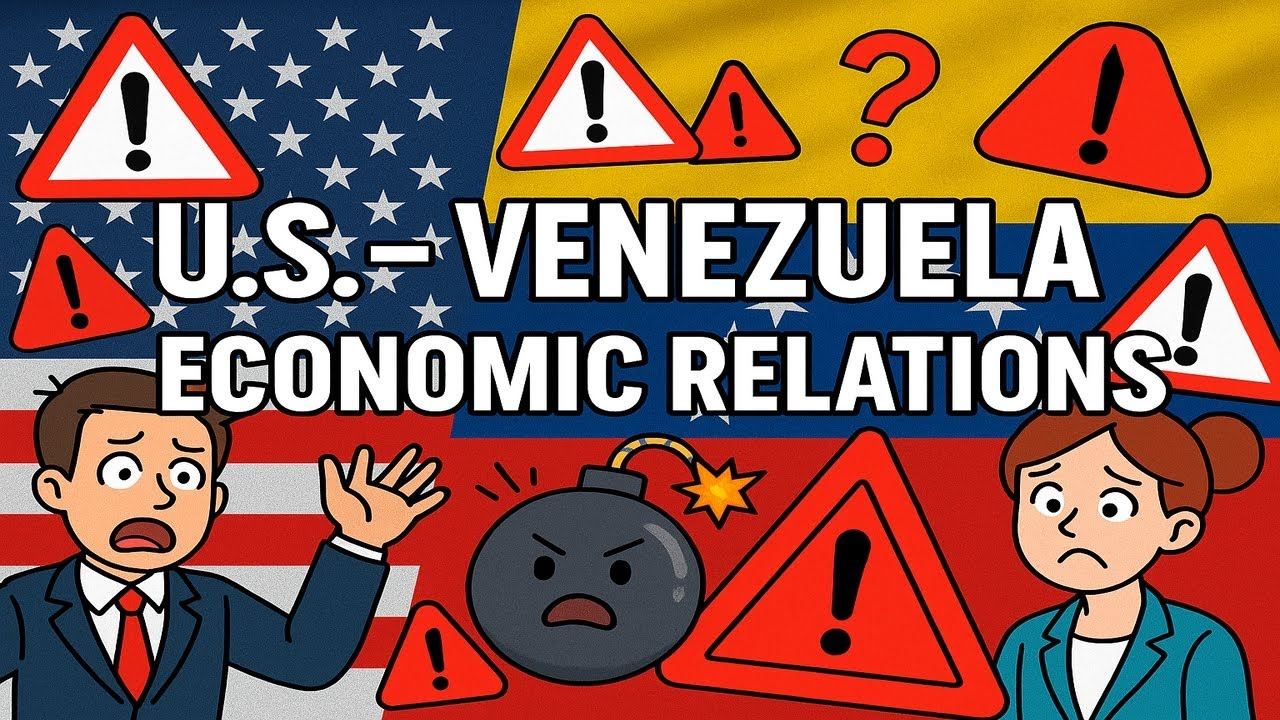

Representative frame:


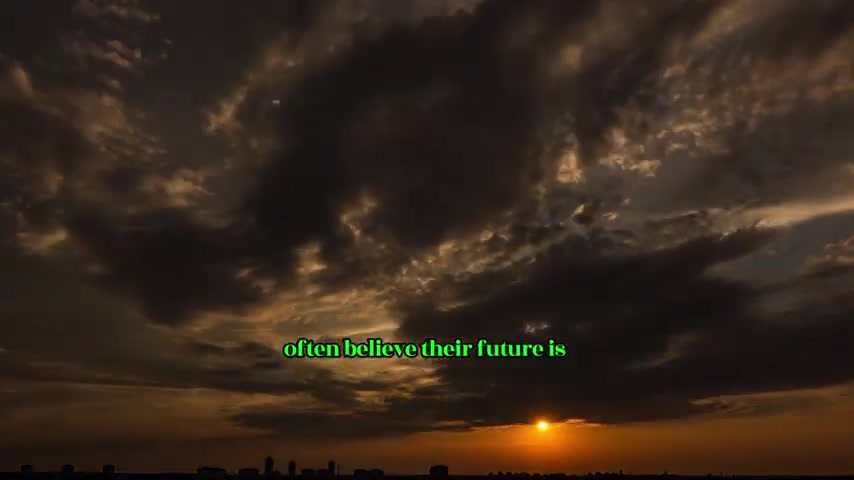


PBS NewsHour (western_legacy) — distance: 11.345
Thumbnail:


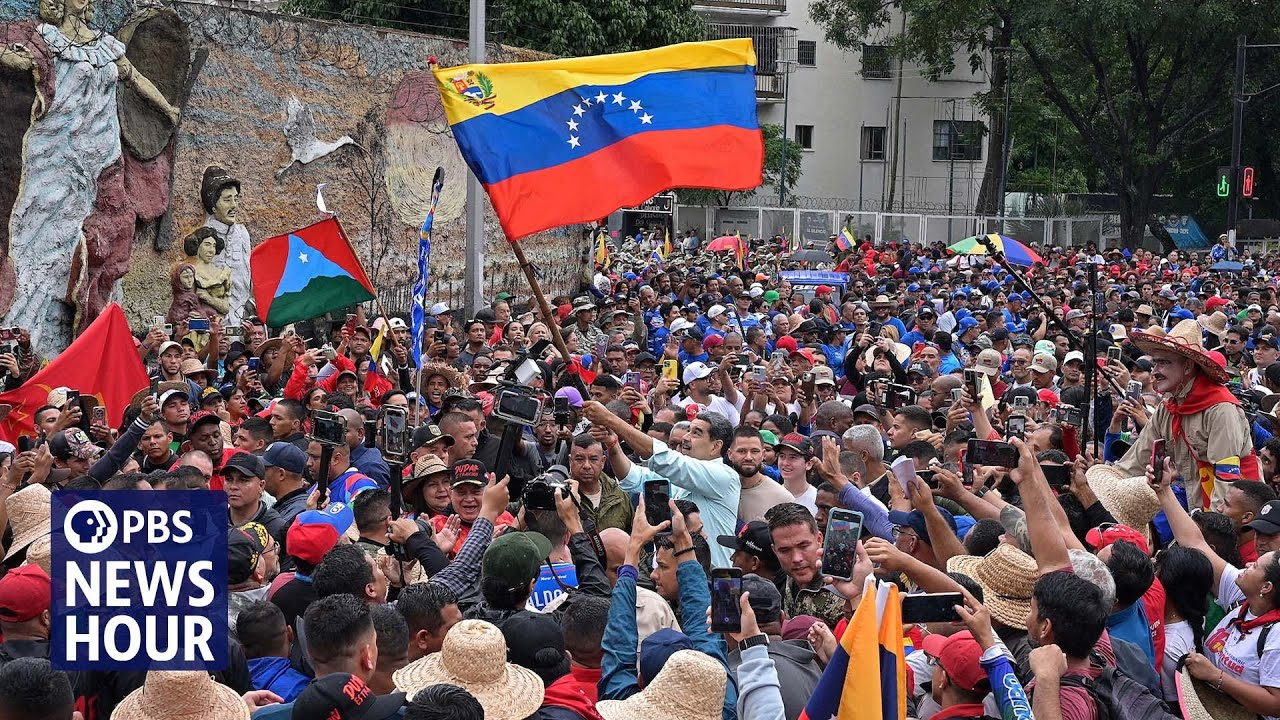

Representative frame:


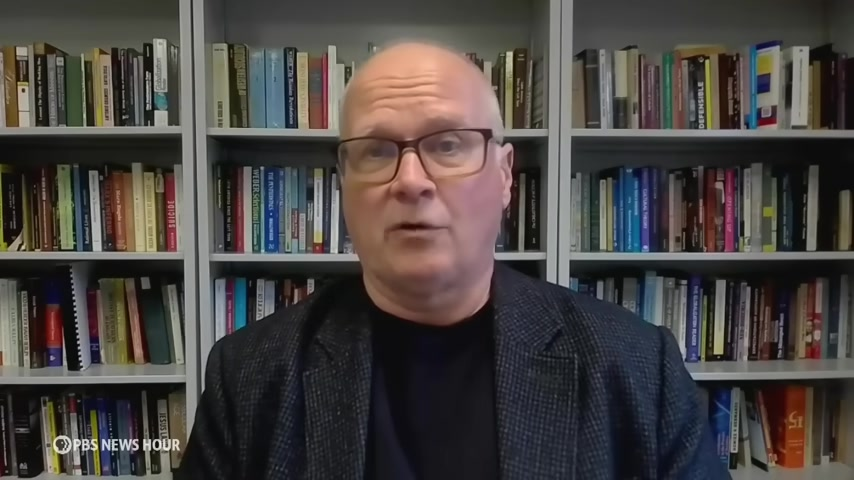


DW News (western_legacy) — distance: 11.239
Thumbnail:


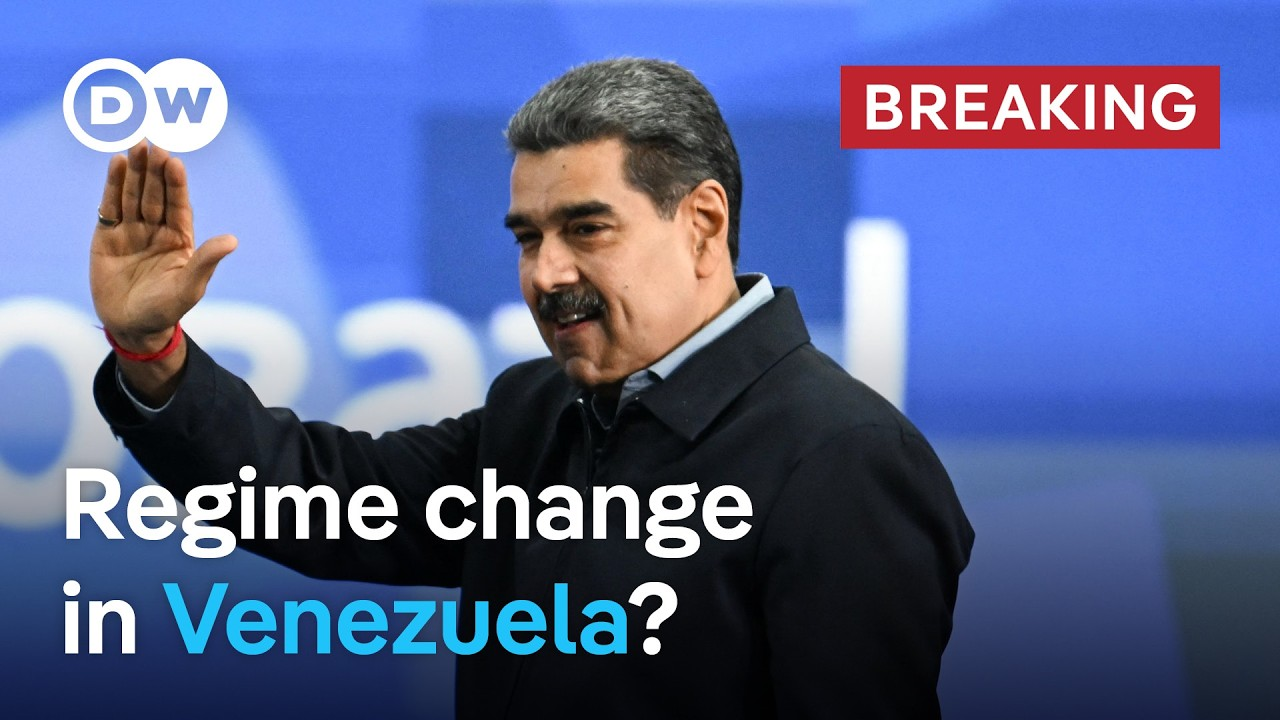

Representative frame:


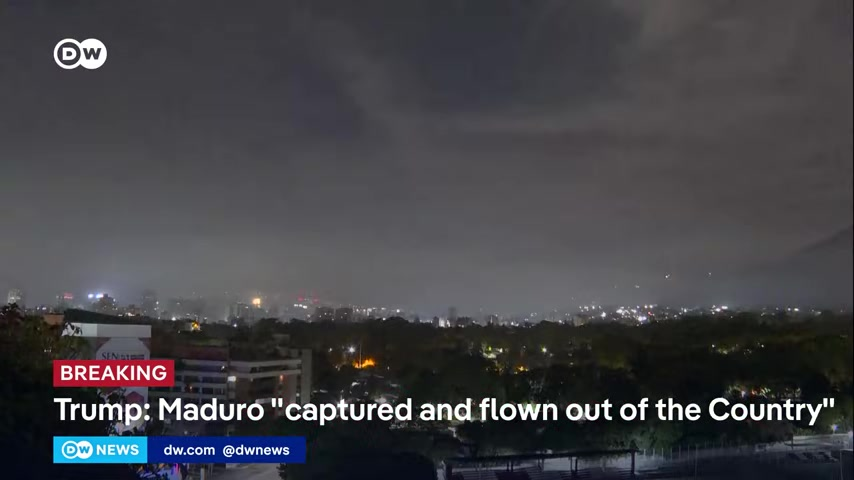


ABC News (western_legacy) — distance: 11.038
Thumbnail:


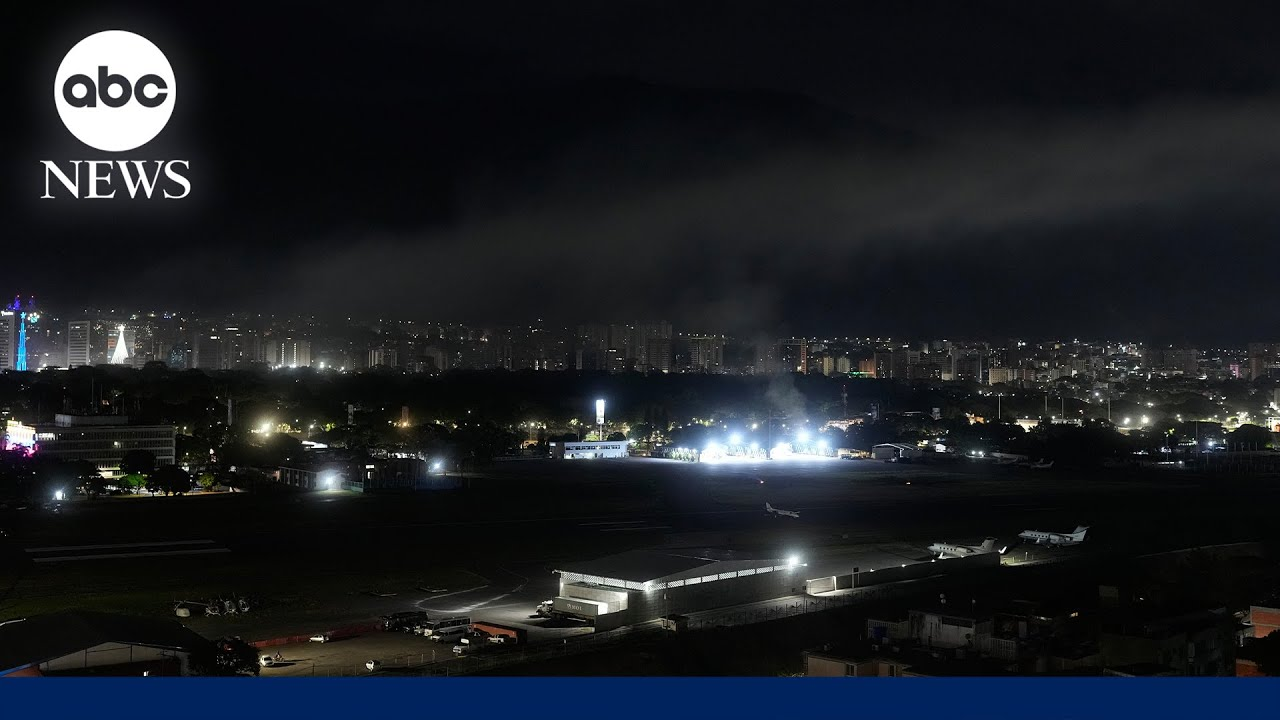

Representative frame:


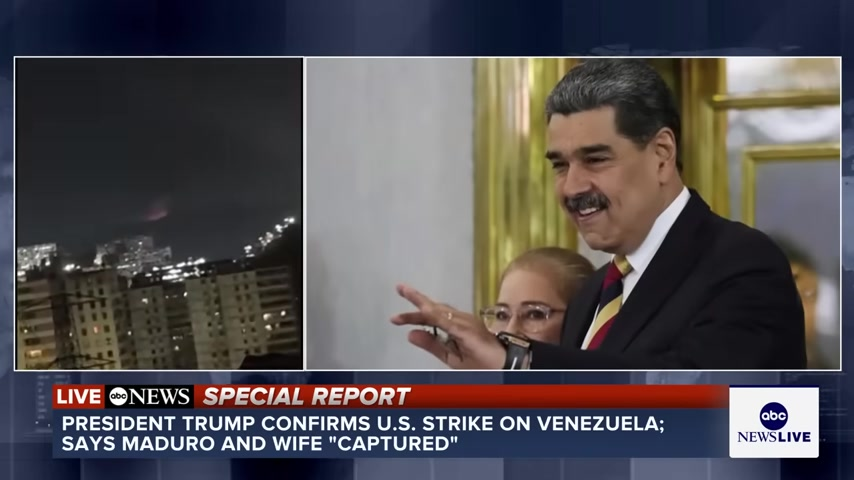


=== LEAST DIVERGENT ===

The Young Turks (independent) — distance: 3.478
Thumbnail:


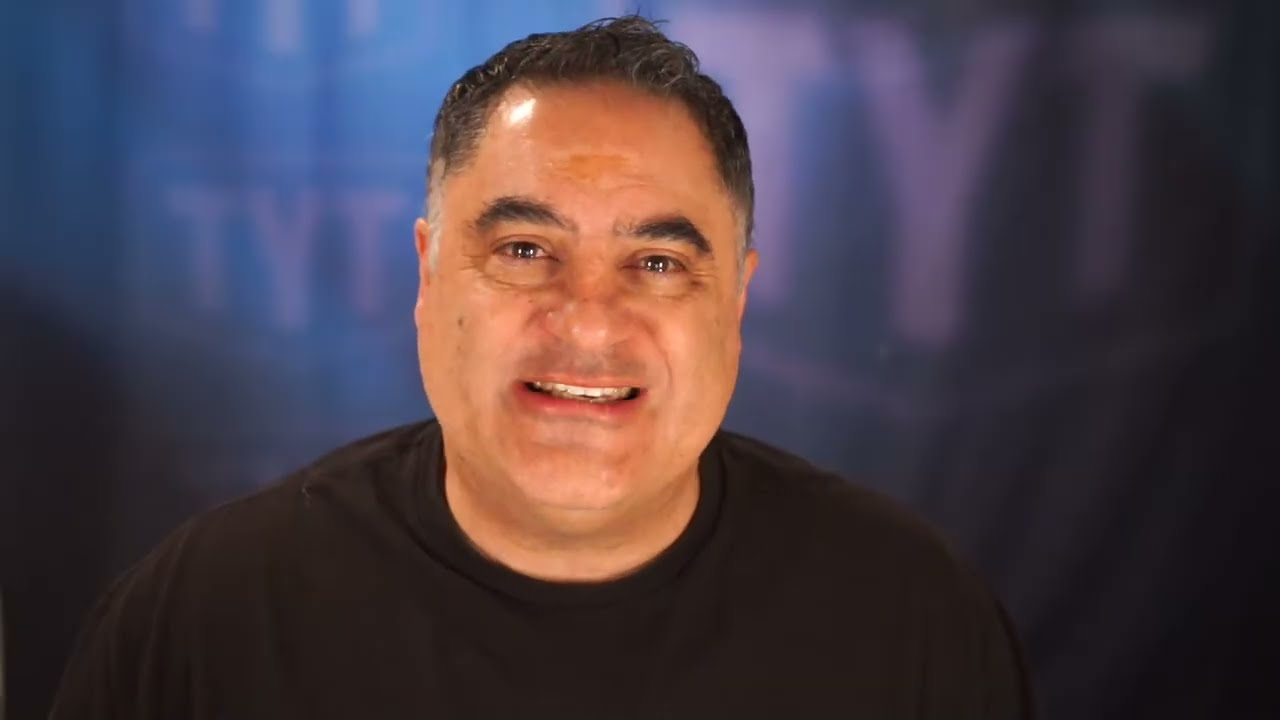

Representative frame:


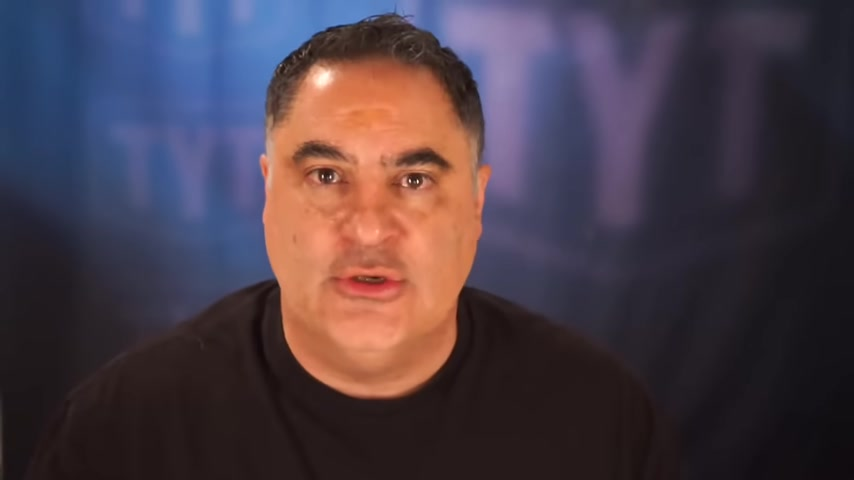


Eyewitness News ABC7NY (western_legacy) — distance: 3.815
Thumbnail:


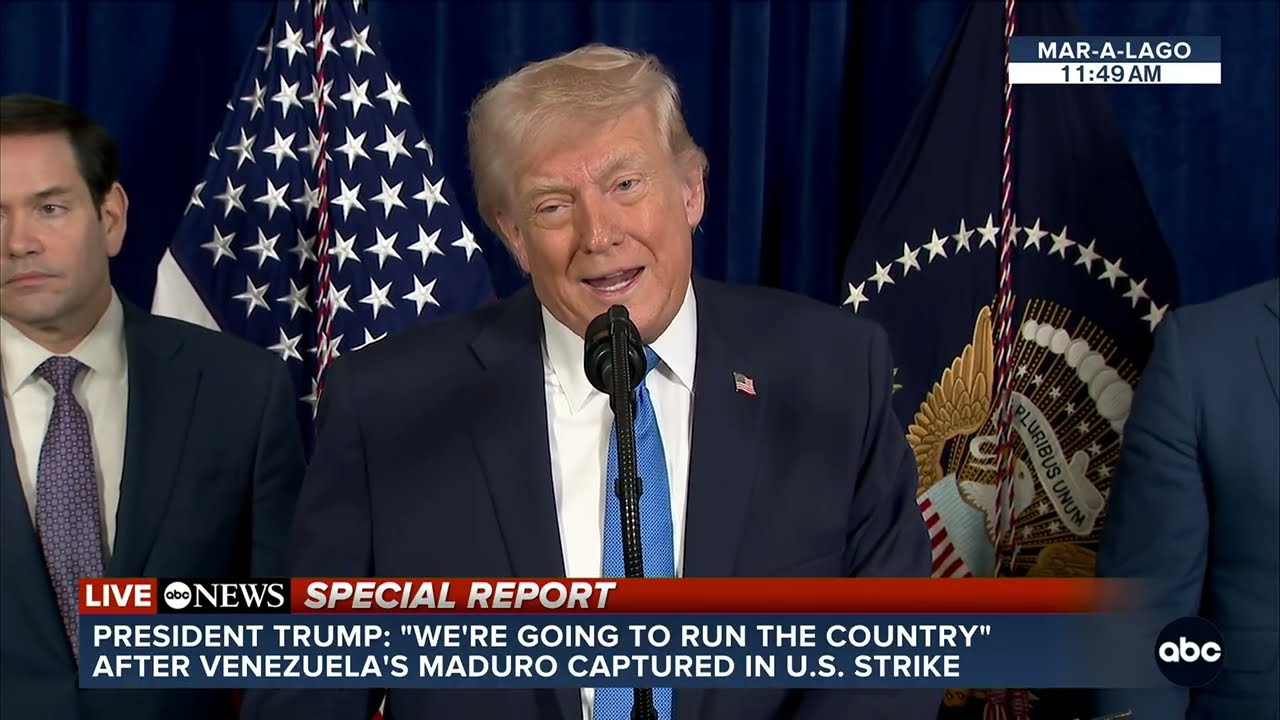

Representative frame:


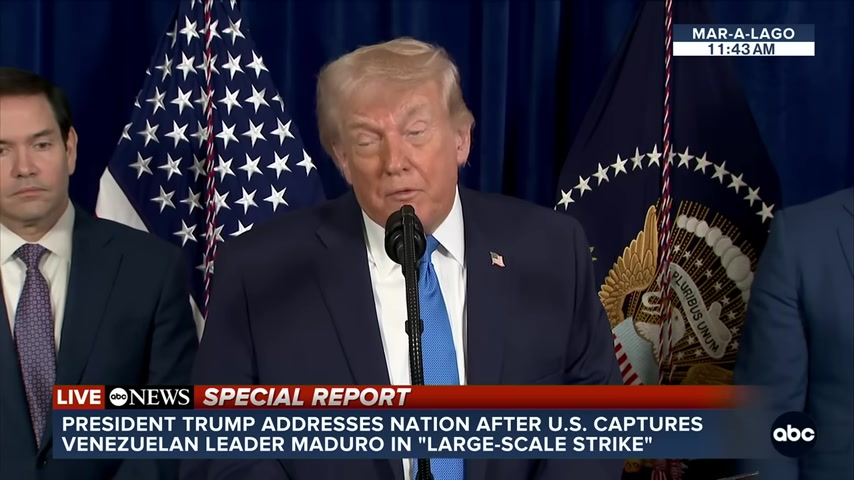


The Wall Street Journal (western_legacy) — distance: 5.261
Thumbnail:


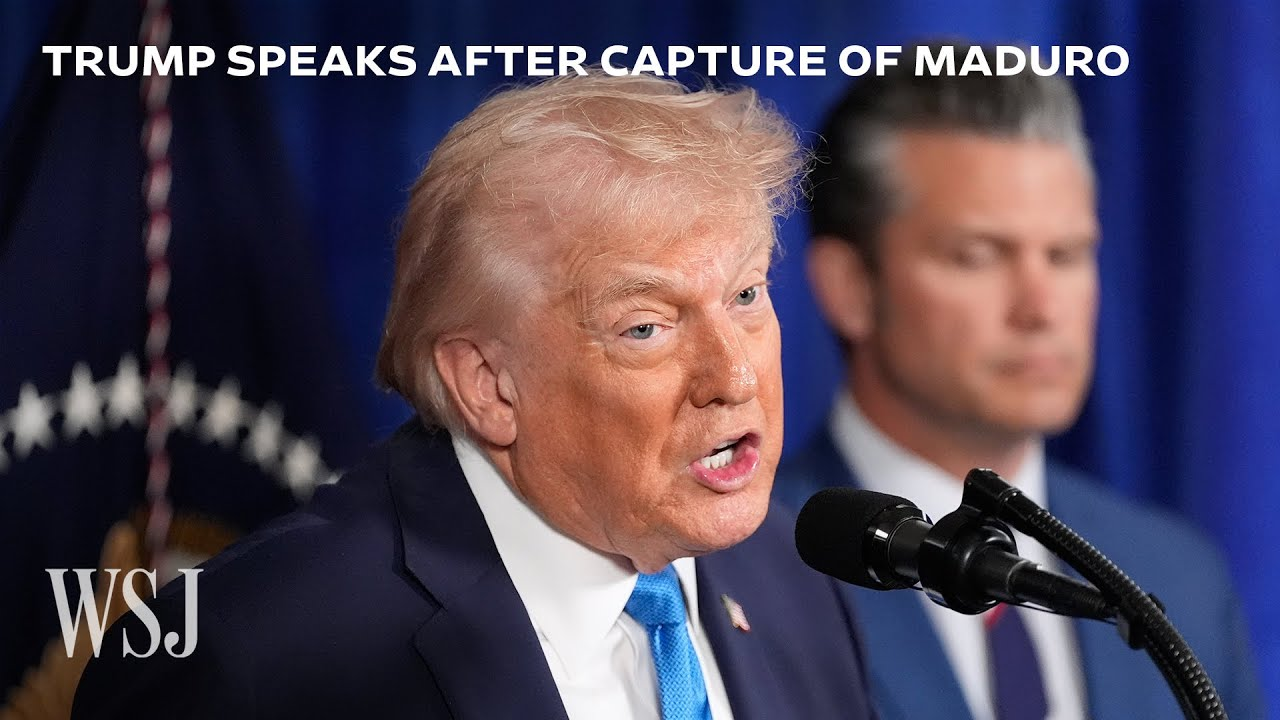

Representative frame:


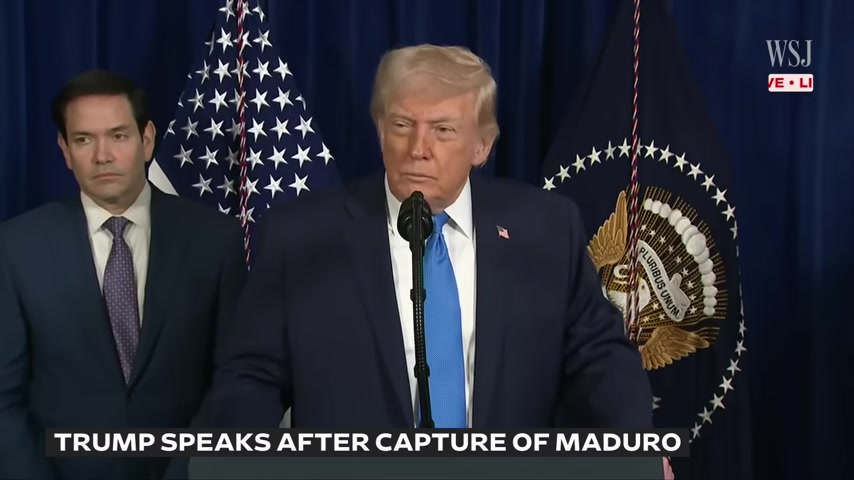


FOX 5 New York (western_legacy) — distance: 5.307
Thumbnail:


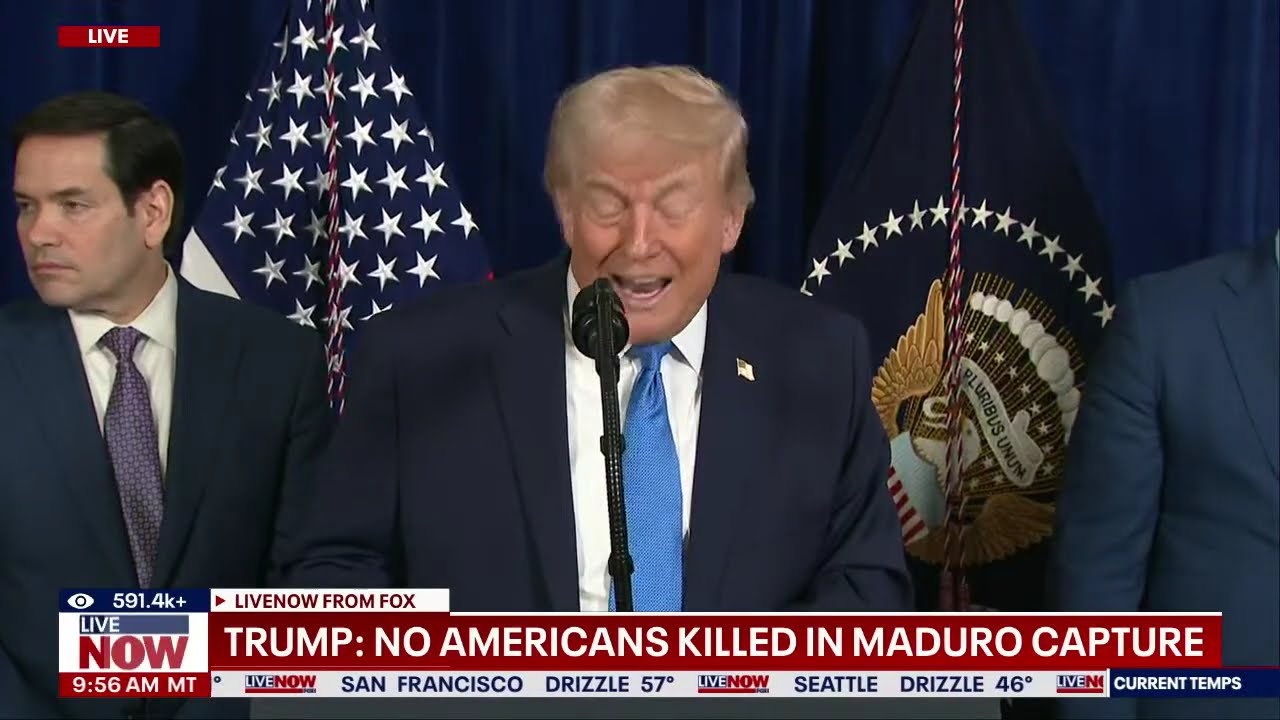

Representative frame:


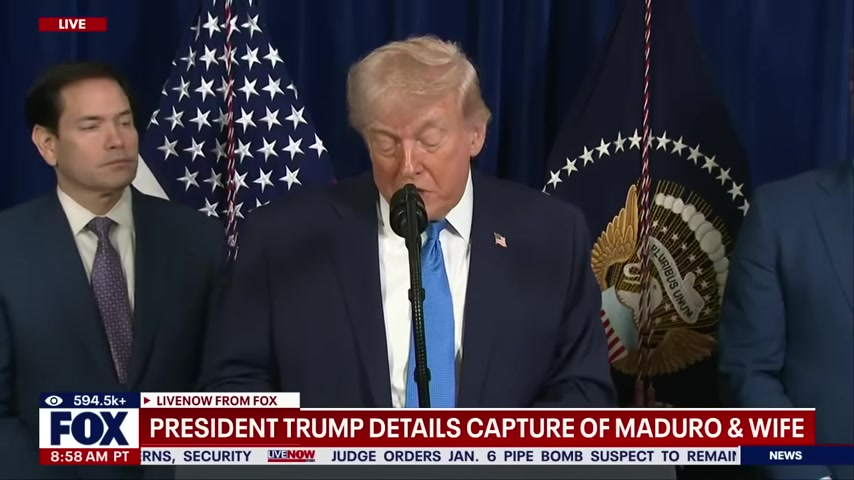

In [85]:
from IPython.display import display, Image as IPImage
import os
import numpy as np
import pandas as pd

# Load metadata and embeddings for get_rep_frame_path
meta = pd.read_csv('/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv')
emb_all = np.load('/content/drive/MyDrive/Thesis/embeddings.npy')

# Align meta to embeddings (using first 30000 rows as established in previous cells)
meta_aligned = meta.iloc[:30000].reset_index(drop=True)
frame_meta = meta_aligned[meta_aligned['label'] == 'frame'].reset_index()
frame_meta.rename(columns={'index': 'emb_index'}, inplace=True)

# Function to get the path of the representative frame
def get_rep_frame_path(video_id):
    group = frame_meta[frame_meta['videoId'] == video_id]
    if len(group) == 0:
        # Return a placeholder path or handle appropriately if no frames found
        return f"No frames found for {video_id}"
    indices = group['emb_index'].values
    vecs = emb_all[indices]
    mean_emb = vecs.mean(axis=0)
    dists = np.linalg.norm(vecs - mean_emb, axis=1)
    rep_idx = indices[dists.argmin()]
    return frame_meta.loc[frame_meta['emb_index'] == rep_idx, 'path'].values[0]

thumb_dir = '/content/drive/MyDrive/Thesis/thesis_thumbnails'

for label, subset in [('MOST DIVERGENT', df_dist.nlargest(4, 'euclidean_distance')),
                       ('LEAST DIVERGENT', df_dist.nsmallest(4, 'euclidean_distance'))]:
    print(f"\n=== {label} ===")
    for _, row in subset.iterrows():
        vid = row['videoId']
        print(f"\n{row['channelTitle']} ({row['outlet_category']}) — distance: {row['euclidean_distance']:.3f}")

        # Show thumbnail
        thumb_path = f"{thumb_dir}/{vid}.jpg"
        if os.path.exists(thumb_path):
            print("Thumbnail:")
            display(IPImage(filename=thumb_path, width=300))

        # Show actual representative frame
        rep_path = get_rep_frame_path(vid)
        if os.path.exists(rep_path) and not rep_path.startswith("No frames found"): # Check if path is valid
            print("Representative frame:")
            display(IPImage(filename=rep_path, width=300))
        else:
            print(f"Representative frame not found: {rep_path}")

In [86]:
import pandas as pd

df_dist = pd.read_csv('/content/drive/MyDrive/Thesis/visual_divergence.csv')

channels_of_interest = [
    'Economy History', 'PBS NewsHour', 'DW News', 'ABC News',
    'The Young Turks', 'Eyewitness News ABC7NY',
    'The Wall Street Journal', 'FOX 5 New York'
]

ids = df_dist[df_dist['channelTitle'].isin(channels_of_interest)][
    ['channelTitle', 'videoId', 'outlet_category', 'euclidean_distance']
].sort_values('euclidean_distance', ascending=False)

print(ids.to_string(index=False))

           channelTitle     videoId outlet_category  euclidean_distance
        Economy History qM2fPIeZKIY     independent           12.116663
           PBS NewsHour hqyXbW7sbU8  western_legacy           11.344635
                DW News GrxKQZIeyis  western_legacy           11.239158
               ABC News JTFLNeLcTdQ  western_legacy           11.038377
           PBS NewsHour Ed85-MolK-4  western_legacy           10.410056
                DW News AdBwca6-sSw  western_legacy           10.292153
The Wall Street Journal WJSJOiYzHRM  western_legacy           10.195112
           PBS NewsHour Rb2r1Kxria8  western_legacy           10.156903
                DW News j_24Tzf2mZ0  western_legacy            9.640592
                DW News oiT-eZJny60  western_legacy            9.474783
                DW News aNvD_JT6nDI  western_legacy            9.404522
         FOX 5 New York 1vH9sfZK_28  western_legacy            8.561995
                DW News UMEm3sIvKl4  western_legacy            8

In [87]:
import numpy as np
import pandas as pd
import os

meta = pd.read_csv('/content/drive/MyDrive/Thesis/embeddings_progress_meta.csv')
emb_all = np.load('/content/drive/MyDrive/Thesis/embeddings.npy')

meta_aligned = meta.iloc[:30000].reset_index(drop=True)
frame_meta = meta_aligned[meta_aligned['label'] == 'frame'].reset_index()
frame_meta.rename(columns={'index': 'emb_index'}, inplace=True)

# Find representative frame path for a specific video
def get_rep_frame_path(video_id):
    group = frame_meta[frame_meta['videoId'] == video_id]
    if len(group) == 0:
        return f"No frames found for {video_id}"
    indices = group['emb_index'].values
    vecs = emb_all[indices]
    mean_emb = vecs.mean(axis=0)
    dists = np.linalg.norm(vecs - mean_emb, axis=1)
    rep_idx = indices[dists.argmin()]
    return frame_meta.loc[frame_meta['emb_index'] == rep_idx, 'path'].values[0]

video_ids = ['qM2fPIeZKIY', 'hqyXbW7sbU8', 'NzYvOphVLGg', 'BuTzfx1KbK8']
for vid in video_ids:
    path = get_rep_frame_path(vid)
    print(f"{vid}: {path}")

qM2fPIeZKIY: /content/drive/MyDrive/Thesis/thesis_frames/qM2fPIeZKIY/frame_0047.jpg
hqyXbW7sbU8: /content/drive/MyDrive/Thesis/thesis_frames/hqyXbW7sbU8/frame_0051.jpg
NzYvOphVLGg: /content/drive/MyDrive/Thesis/thesis_frames/NzYvOphVLGg/frame_0134.jpg
BuTzfx1KbK8: /content/drive/MyDrive/Thesis/thesis_frames/BuTzfx1KbK8/frame_0030.jpg


In [88]:
category_labels = {
    "western_legacy": "Western Legacy",
    "indian_hybrid": "Indian and Asian Platform-Hybrid",
    "latin_american": "Latin American",
    "independent": "Independent and Commentary"
}

top10 = df_dist.nlargest(10, 'euclidean_distance')

fig = px.bar(
    top10,
    y='channelTitle',
    x='euclidean_distance',
    color='outlet_category',
    orientation='h',
    title='Top 10 Most Divergent Videos by Euclidean Distance',
    labels={
        'euclidean_distance': 'Euclidean Distance',
        'channelTitle': 'Channel',
        'outlet_category': 'Outlet Category'
    },
    height=500,
    width=900
)

for trace in fig.data:
    if trace.name in category_labels:
        trace.name = category_labels[trace.name]

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}
)

fig.write_image(
    '/content/drive/MyDrive/Thesis/figures/top10_visual_divergence.png',
    scale=2
)

fig.show()

In [116]:
import pandas as pd
import plotly.express as px

# Load visual divergence with dates
df_dist = pd.read_csv('/content/drive/MyDrive/Thesis/visual_divergence.csv')
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

# Merge to get publishedAt
df_dist = df_dist.merge(
    df_main[['videoId', 'publishedAt']],
    on='videoId', how='left'
)

# Floor to month
df_dist['month'] = pd.to_datetime(df_dist['publishedAt']).dt.to_period('M').astype(str)

# Monthly mean distance overall
monthly_mean = df_dist.groupby('month')['euclidean_distance'].agg(['mean', 'count']).round(3).reset_index()
print("=== Monthly mean Euclidean distance ===")
print(monthly_mean.to_string())

# Monthly mean distance per outlet category
monthly_cat = df_dist.groupby(['month', 'outlet_category'])['euclidean_distance'].mean().round(3).reset_index()
print("\n=== Monthly mean distance per category ===")
print(monthly_cat.to_string())

# Plot overall
fig1 = px.line(
    monthly_mean, x='month', y='mean',
    title='Mean Visual Divergence Over Time',
    labels={'mean': 'Mean Euclidean Distance', 'month': 'Month'},
    height=500, width=1000
)
fig1.write_image('/content/drive/MyDrive/Thesis/figures/divergence_over_time.png', scale=2)
fig1.show()

# Plot per outlet category
category_labels = {
    "western_legacy": "Western Legacy",
    "indian_hybrid": "Indian and Asian Platform-Hybrid",
    "latin_american": "Latin American",
    "independent": "Independent and Commentary"
}

fig2 = px.line(
    monthly_cat,
    x='month',
    y='euclidean_distance',
    color='outlet_category',
    title='Mean Visual Divergence Over Time by Outlet Category',
    labels={
        'euclidean_distance': 'Mean Euclidean Distance',
        'month': 'Month',
        'outlet_category': 'Outlet Category'
    },
    height=500,
    width=1000
)

for trace in fig2.data:
    if trace.name in category_labels:
        trace.name = category_labels[trace.name]

fig2.write_image(
    '/content/drive/MyDrive/Thesis/figures/divergence_over_time_by_category.png',
    scale=2
)

fig2.show()

=== Monthly mean Euclidean distance ===
     month   mean  count
0  2025-09  6.904      1
1  2025-10  9.470      8
2  2025-11  9.411     15
3  2025-12  9.272     29
4  2026-01  8.581     82
5  2026-02  9.449      5
6  2026-03  9.172      5
7  2026-04  9.270      5

=== Monthly mean distance per category ===
      month outlet_category  euclidean_distance
0   2025-09     independent               6.904
1   2025-10     independent               9.351
2   2025-10   indian_hybrid               6.383
3   2025-10  western_legacy              10.004
4   2025-11     independent              10.152
5   2025-11   indian_hybrid               8.526
6   2025-11  western_legacy               9.422
7   2025-12     independent               8.869
8   2025-12   indian_hybrid               8.651
9   2025-12  latin_american               9.209
10  2025-12  western_legacy               9.584
11  2026-01     independent               8.672
12  2026-01   indian_hybrid               9.499
13  2026-01  latin_

/tmp/ipykernel_7175/3710264797.py:15: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [90]:
import pandas as pd

df_div = pd.read_csv('/content/drive/MyDrive/Thesis/affect_comparison.csv')
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')

# Merge to get viewCount
df_div = df_div.merge(df_main[['videoId', 'viewCount']], on='videoId', how='left')

# Find neutral thumbnails with threatening transcripts
neutral_threatening = df_div[
    (df_div['dominant_affect'] == 'a neutral and informative image') &
    (df_div['transcript_dominant_affect'] == 'a threatening and dangerous image')
][['videoId', 'channelTitle', 'outlet_category', 'viewCount']].sort_values('viewCount', ascending=False)

print(neutral_threatening.head(10).to_string())

        videoId             channelTitle outlet_category  viewCount
0   NiSuZilaClQ                  AiTelly     independent    9168815
1   Pgwny1BiCYk                 Sky News  western_legacy    4665060
2   d-Mh-ndtqAY             RealLifeLore     independent    3873434
3   K8QYuG8Qb44                 NBC News  western_legacy    3162591
4   3n0HulTEDYI                  AiTelly     independent    2472150
11  UoMdIMGA798         Across The Globe     independent    1408990
15  IIpgOGWc7Ug                 CBC News  western_legacy    1208721
16  WtSGiuyT_wE                 CBC News  western_legacy    1195696
24  WJSJOiYzHRM  The Wall Street Journal  western_legacy     719628
26  okFXXXWlKBQ     The Rest Is Politics     independent     706073


In [91]:
df_main = pd.read_csv('/content/drive/MyDrive/Thesis/cleaned_dataset.csv')
latin = df_main[df_main['outlet_category'] == 'latin_american'][['videoId', 'channelTitle', 'viewCount']].sort_values('viewCount', ascending=False)
print(latin.head(5).to_string())

        videoId        channelTitle  viewCount
77  9a-yxY14Qso  Noticias Telemundo    2007549
45  bpi5guMrT8s        MEGA Oficial     833057
8   Mey7ACPc9vs             TuBarco     682549
39  3Zf_DZ-ZfYo      Mundo Comunica     448357
43  s_b3dZNz-_4                NMás     394786


In [92]:
indian = df_main[df_main['outlet_category'] == 'indian_hybrid'][['videoId', 'channelTitle', 'viewCount']].sort_values('viewCount', ascending=False)
print(indian.head(5).to_string())

        videoId    channelTitle  viewCount
95  OGwXX-5WSX0  Times Of India    1652417
50  WFk2Hd3mvJM       Firstpost     776552
82  iljmLs-mvOA  Times Of India     438440
34  QnqOhPUYcjg       Firstpost     376385
94  0zqdFso3-Qw  Times Of India     336795


In [93]:
df_dist = pd.read_csv('/content/drive/MyDrive/Thesis/visual_divergence.csv')
row = df_dist[df_dist['videoId'] == 'OGwXX-5WSX0']
print(row[['videoId', 'channelTitle', 'euclidean_distance']].to_string())

        videoId    channelTitle  euclidean_distance
95  OGwXX-5WSX0  Times Of India              9.7582


# Temporal Analysis (Longitudinal)

Independent and commentary channel category was excluded from the longitudinal analysis as the top channels did not fit the research question.

In [94]:
import pandas as pd

# Load your cleaned dataset if not already in memory
if 'cleaned_df' not in dir():
    cleaned_df = pd.read_csv("/content/drive/MyDrive/Thesis/cleaned_dataset.csv")
    cleaned_df["publishedAt"] = pd.to_datetime(cleaned_df["publishedAt"])

# Reconstruct channel_stats
channel_stats = (
    cleaned_df.groupby(["channelId", "channelTitle", "outlet_category"])
    .agg(
        n_videos=("videoId", "count"),
        n_active_months=("publishedAt", lambda x: x.dt.to_period("M").nunique()),
        date_range_days=("publishedAt", lambda x: (x.max() - x.min()).days)
    )
    .reset_index()
)

print(channel_stats.head())
print(f"Total channels: {len(channel_stats)}")

                  channelId       channelTitle outlet_category  n_videos  \
0  UC16niRr50-MSBwiO3YDb3RA           BBC News  western_legacy         7   
1  UC1FZF46zaC26_CynNc786_g      Gestión Mundo  latin_american         1   
2  UC1yBKRuGpC1tSM73A0ZjYjQ    The Young Turks     independent         1   
3  UC3prwMn9aU2z5Y158ZdGyyA               CRUX   indian_hybrid         1   
4  UC4e-87tzDuHYE0RNTjqYOPQ  Baby News Network     independent         2   

   n_active_months  date_range_days  
0                2               41  
1                1                0  
2                1                0  
3                1                0  
4                2               39  
Total channels: 73


/tmp/ipykernel_7175/827913639.py:13: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [95]:
# Check top 10 for all categories
for category in sorted(channel_stats['outlet_category'].unique()):
    ranked = (
        channel_stats[
            (channel_stats['outlet_category'] == category) &
            (channel_stats['n_active_months'] >= 2)
        ]
        .sort_values(['n_active_months', 'n_videos'], ascending=False)
        .head(10)
        [['channelTitle', 'channelId', 'n_videos', 'n_active_months', 'date_range_days']]
        .reset_index(drop=True)
    )
    print(f"=== {category} ===")
    if ranked.empty:
        print("No channels meeting 3 active months threshold")
    else:
        print(ranked.to_string(index=False))
    print()

=== independent ===
         channelTitle                channelId  n_videos  n_active_months  date_range_days
    Baby News Network UC4e-87tzDuHYE0RNTjqYOPQ         2                2               39
The Infographics Show UCfdNM3NAhaBOXCafH7krzrA         2                2               51
             Moconomy UCoOHTipX1_cNiC9seIPfUXA         2                2               35

=== indian_hybrid ===
      channelTitle                channelId  n_videos  n_active_months  date_range_days
    Times Of India UCckHqySbfy5FcPP6MD_S-Yg         9                3               57
         Firstpost UCz8QaiQxApLq8sLNcszYyJw         6                3               60
The Economic Times UCJFOER35ggIWwsXh2ZDnqyg         2                2               24
              WION UC_gUM8rL-Lrg6O3adPW9K1g         2                2               60

=== latin_american ===
channelTitle                channelId  n_videos  n_active_months  date_range_days
Meganoticias UCkccyEbqhhM3uKOI6Shm-4Q         2

Times of India (Indian hybrid), Meganoticias (Latin American), and CBS News (Western legacy) were chosen as the top channels per outlet category for individual longitudinal analysis. New datasets retrieved on May 14 and 15, 2026.

Check if the upload histories of the channels go back far enough.

In [96]:
# df_channel_independent = pd.read_csv('/content/drive/MyDrive/Thesis/channel_independent.csv')

# print(len(df_channel_independent))  # how many videos came back
# print(df_channel_independent['publishedAt'].min())  # earliest video
# print(df_channel_independent['publishedAt'].max())  # latest video

In [97]:
# Times of India channel
df_toi = pd.read_csv('/content/drive/MyDrive/Thesis/channel_indian_toi.csv')

df_toi['publishedAt'] = pd.to_datetime(df_toi['publishedAt'])

print(len(df_toi))
print(df_toi['publishedAt'].min())
print(df_toi['publishedAt'].max())

over_5min = df_toi[df_toi['durationSec'] >= 300]
print(f"Over 5 minutes: {len(over_5min)}")
print(f"Under 5 minutes: {len(df_toi) - len(over_5min)}")

20000
2025-05-28 05:15:45+00:00
2026-05-14 13:01:10+00:00
Over 5 minutes: 13939
Under 5 minutes: 6061


In [98]:
# CBS News channel
df_cbs = pd.read_csv('/content/drive/MyDrive/Thesis/channel_western_cbs.csv')

df_cbs['publishedAt'] = pd.to_datetime(df_cbs['publishedAt'])

print(len(df_cbs))
print(df_cbs['publishedAt'].min())
print(df_cbs['publishedAt'].max())

over_5min = df_cbs[df_cbs['durationSec'] >= 300]
print(f"Over 5 minutes: {len(over_5min)}")
print(f"Under 5 minutes: {len(df_cbs) - len(over_5min)}")

20000
2024-12-10 20:32:20+00:00
2026-05-15 13:58:41+00:00
Over 5 minutes: 7467
Under 5 minutes: 12533


In [99]:
# Meganoticias channel
df_mega = pd.read_csv('/content/drive/MyDrive/Thesis/channel_latin_mega.csv')

df_mega['publishedAt'] = pd.to_datetime(df_mega['publishedAt'])

print(len(df_mega))
print(df_mega['publishedAt'].min())
print(df_mega['publishedAt'].max())

over_5min = df_mega[df_mega['durationSec'] >= 300]
print(f"Over 5 minutes: {len(over_5min)}")
print(f"Under 5 minutes: {len(df_mega) - len(over_5min)}")

20000
2025-05-09 16:50:54+00:00
2026-05-15 15:31:20+00:00
Over 5 minutes: 8419
Under 5 minutes: 11581


# Set Up Cell (Longitudinal)


In [100]:
# Set up cell for longitudinal analysis

import pandas as pd

def load_channel(filepath, channel_name):
    df = pd.read_csv(filepath)
    df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)
    df = df.drop_duplicates(subset='videoId')
    df = df[df['durationSec'] >= 300]
    df = df[df['publishedAt'] >= '2020-01-01']
    df['channel_name'] = channel_name
    print(f"{channel_name}: {len(df)} videos after cleaning")
    print(f"Date range: {df['publishedAt'].min()} to {df['publishedAt'].max()}")
    return df

channels = {
    'times_of_india': load_channel('/content/drive/MyDrive/Thesis/channel_indian_toi.csv', 'Times Of India'),
    'cbs_news':       load_channel('/content/drive/MyDrive/Thesis/channel_western_cbs.csv', 'CBS News'),
    'meganoticias':   load_channel('/content/drive/MyDrive/Thesis/channel_latin_mega.csv', 'Meganoticias'),
}

Times Of India: 13939 videos after cleaning
Date range: 2025-05-28 05:15:45+00:00 to 2026-05-14 13:01:10+00:00
CBS News: 7467 videos after cleaning
Date range: 2024-12-10 20:32:20+00:00 to 2026-05-15 12:58:16+00:00
Meganoticias: 8419 videos after cleaning
Date range: 2025-05-09 16:50:54+00:00 to 2026-05-15 14:39:05+00:00


In [101]:
import os, requests, pandas as pd
from tqdm import tqdm

def download_channel_thumbnails(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
    save_dir = f"{base_dir}/{channel_name}"
    os.makedirs(save_dir, exist_ok=True)
    failed = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=channel_name):
        vid = str(row['videoId'])
        url = row['thumbnail_maxres']
        out = f"{save_dir}/{vid}.jpg"
        if os.path.exists(out):
            continue
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                with open(out, 'wb') as f:
                    f.write(r.content)
            else:
                failed.append(vid)
        except:
            failed.append(vid)

    downloaded = len([f for f in os.listdir(save_dir) if f.endswith('.jpg')])
    print(f"{channel_name}: {downloaded} thumbnails saved, {len(failed)} failed")
    return failed

failed_toi  = download_channel_thumbnails(channels['times_of_india'],  'times_of_india')
failed_cbs  = download_channel_thumbnails(channels['cbs_news'],        'cbs_news')
failed_mega = download_channel_thumbnails(channels['meganoticias'],    'meganoticias')

times_of_india: 100%|██████████| 13939/13939 [00:10<00:00, 1316.11it/s]


times_of_india: 13876 thumbnails saved, 63 failed


cbs_news: 100%|██████████| 7467/7467 [00:04<00:00, 1802.04it/s]


cbs_news: 7454 thumbnails saved, 13 failed


meganoticias: 100%|██████████| 8419/8419 [00:03<00:00, 2312.58it/s]


meganoticias: 8371 thumbnails saved, 48 failed


In [102]:
def verify_thumbnails(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
    thumb_dir = f"{base_dir}/{channel_name}"
    downloaded = set([f.replace('.jpg', '') for f in os.listdir(thumb_dir) if f.endswith('.jpg')])
    expected   = set(df['videoId'].astype(str))
    missing    = expected - downloaded
    extra      = downloaded - expected

    print(f"{channel_name}:")
    print(f"  Expected : {len(expected)}")
    print(f"  Downloaded: {len(downloaded)}")
    print(f"  Missing  : {len(missing)}")
    print(f"  Extra    : {len(extra)}")

verify_thumbnails(channels['times_of_india'],  'times_of_india')
verify_thumbnails(channels['cbs_news'],        'cbs_news')
verify_thumbnails(channels['meganoticias'],    'meganoticias')

times_of_india:
  Expected : 13939
  Downloaded: 13876
  Missing  : 63
  Extra    : 0
cbs_news:
  Expected : 7467
  Downloaded: 7454
  Missing  : 13
  Extra    : 0
meganoticias:
  Expected : 8419
  Downloaded: 8371
  Missing  : 48
  Extra    : 0


Clip embeddings for longitudinal corpus.

In [103]:
import open_clip
import torch
from PIL import Image
import numpy as np
import json
import os
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model = model.to(device).eval()

def compute_clip_embeddings(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
    thumb_dir = f"{base_dir}/{channel_name}"
    save_path = f"/content/drive/MyDrive/Thesis/channel_embeddings/{channel_name}_embeddings.npy"
    id_path   = f"/content/drive/MyDrive/Thesis/channel_embeddings/{channel_name}_ids.json"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Resume from existing
    if os.path.exists(id_path):
        existing_ids = set(json.load(open(id_path)))
    else:
        existing_ids = set()

    embeddings = list(np.load(save_path)) if os.path.exists(save_path) else []
    video_ids  = list(existing_ids)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"CLIP {channel_name}"):
        vid = str(row['videoId'])
        if vid in existing_ids:
            continue
        path = f"{thumb_dir}/{vid}.jpg"
        if not os.path.exists(path):
            continue
        try:
            img = preprocess(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad():
                emb = model.encode_image(img).cpu().numpy().flatten()
            embeddings.append(emb)
            video_ids.append(vid)
            existing_ids.add(vid)
        except Exception as e:
            print(f"Failed: {vid} — {e}")

        if len(embeddings) % 500 == 0:
            np.save(save_path, np.array(embeddings))
            json.dump(video_ids, open(id_path, 'w'))

    np.save(save_path, np.array(embeddings))
    json.dump(video_ids, open(id_path, 'w'))
    print(f"Saved {len(embeddings)} embeddings for {channel_name}")

compute_clip_embeddings(channels['times_of_india'], 'times_of_india')
compute_clip_embeddings(channels['cbs_news'],       'cbs_news')
compute_clip_embeddings(channels['meganoticias'],   'meganoticias')

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning:

QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).

CLIP times_of_india: 100%|██████████| 13939/13939 [00:00<00:00, 22610.06it/s]


Saved 13876 embeddings for times_of_india


CLIP cbs_news: 100%|██████████| 7467/7467 [00:00<00:00, 16572.20it/s]


Saved 7454 embeddings for cbs_news


CLIP meganoticias: 100%|██████████| 8419/8419 [00:00<00:00, 14136.54it/s]


Saved 8371 embeddings for meganoticias


# Color Analysis (Longitudinal)

In [104]:
import cv2
import pandas as pd
import os
from tqdm import tqdm

def compute_colour_features(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
    os.makedirs('/content/drive/MyDrive/Thesis/channel_features', exist_ok=True)
    thumb_dir = f"{base_dir}/{channel_name}"
    save_path = f"/content/drive/MyDrive/Thesis/channel_features/{channel_name}_colour.csv"

    # Resume from existing
    if os.path.exists(save_path):
        existing = pd.read_csv(save_path)
        processed_ids = set(existing['videoId'].astype(str))
        results = existing.to_dict('records')
        print(f"Resuming {channel_name} from {len(results)} already processed")
    else:
        processed_ids = set()
        results = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Colour {channel_name}"):
        vid = str(row['videoId'])
        if vid in processed_ids:
            continue
        path = f"{thumb_dir}/{vid}.jpg"
        if not os.path.exists(path):
            continue
        try:
            img_bgr = cv2.imread(path)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
            results.append({
                'videoId':     vid,
                'mean_r':      img_rgb[:,:,0].mean(),
                'mean_g':      img_rgb[:,:,1].mean(),
                'mean_b':      img_rgb[:,:,2].mean(),
                'mean_sat':    img_hsv[:,:,1].mean(),
                'mean_bright': img_hsv[:,:,2].mean(),
            })
            processed_ids.add(vid)
        except Exception as e:
            print(f"Failed: {vid} — {e}")

        if len(results) % 500 == 0 and len(results) > 0:
            pd.DataFrame(results).to_csv(save_path, index=False)

    df_colour = pd.DataFrame(results)
    df_colour.to_csv(save_path, index=False)
    print(f"Saved colour features for {channel_name}: {len(df_colour)} videos")
    return df_colour

colour_toi  = compute_colour_features(channels['times_of_india'], 'times_of_india')
colour_cbs  = compute_colour_features(channels['cbs_news'],       'cbs_news')
colour_mega = compute_colour_features(channels['meganoticias'],   'meganoticias')


Resuming times_of_india from 13876 already processed


Colour times_of_india: 100%|██████████| 13939/13939 [00:00<00:00, 22837.49it/s]


Saved colour features for times_of_india: 13876 videos
Resuming cbs_news from 7454 already processed


Colour cbs_news: 100%|██████████| 7467/7467 [00:00<00:00, 25427.14it/s]


Saved colour features for cbs_news: 7454 videos
Resuming meganoticias from 8371 already processed


Colour meganoticias: 100%|██████████| 8419/8419 [00:00<00:00, 24709.88it/s]


Saved colour features for meganoticias: 8371 videos


In [105]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/all_channels_monthly.csv')

# Saturation stats per channel
print("=== Saturation per channel ===")
sat_stats = df.groupby('channel_name')['mean_sat'].agg(['mean', 'min', 'max', 'std']).round(2)
print(sat_stats)

# Saturation over time per channel
print("\n=== Saturation by month per channel ===")
for channel in df['channel_name'].unique():
    subset = df[df['channel_name'] == channel].sort_values('month')
    print(f"\n{channel}:")
    print(subset[['month', 'mean_sat']].to_string(index=False))

=== Saturation per channel ===
                  mean     min     max   std
channel_name                                
CBS News         90.60   84.61   99.39  3.78
Meganoticias     95.78   88.67  103.73  4.86
Times Of India  106.62  102.45  112.11  2.84

=== Saturation by month per channel ===

Times Of India:
  month   mean_sat
2025-05 109.479520
2025-06 108.940095
2025-07 106.275280
2025-08 103.848812
2025-09 107.249032
2025-10 112.112772
2025-11 109.490036
2025-12 106.211113
2026-01 106.946093
2026-02 104.766386
2026-03 102.906714
2026-04 105.419149
2026-05 102.448155

CBS News:
  month  mean_sat
2024-12 92.771307
2025-01 99.393372
2025-02 92.530886
2025-03 90.030469
2025-04 89.268199
2025-05 96.888091
2025-06 88.699665
2025-07 87.664989
2025-08 92.598566
2025-09 95.034441
2025-10 87.281387
2025-11 91.032773
2025-12 86.464426
2026-01 90.059991
2026-02 84.613640
2026-03 86.924713
2026-04 89.288641
2026-05 90.216103

Meganoticias:
  month   mean_sat
2025-05  89.455467
2025-06  92.98

# Affective Scoring (Longitudinal)

In [106]:
# import open_clip
# import torch
# from PIL import Image
# import pandas as pd
# import os
# from tqdm import tqdm

# # Setup model
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
# model = model.to(device).eval()

# # Affective prompts
# affective_prompts = [
#     "a threatening and dangerous image",
#     "an urgent and alarming image",
#     "a neutral and informative image",
#     "a dramatic and emotional image",
#     "a calm and reassuring image",
#     "a fearful and anxious image"
# ]

# # Function
# def compute_affect_scores(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
#     os.makedirs('/content/drive/MyDrive/Thesis/channel_features', exist_ok=True)
#     thumb_dir = f"{base_dir}/{channel_name}"
#     tokenizer = open_clip.get_tokenizer('ViT-B-32')
#     text_tokens = tokenizer(affective_prompts).to(device)

#     with torch.no_grad():
#         text_embs = model.encode_text(text_tokens)
#         text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)

#     results = []
#     for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Affect {channel_name}"):
#         vid = str(row['videoId'])
#         path = f"{thumb_dir}/{vid}.jpg"
#         if not os.path.exists(path):
#             continue
#         try:
#             img = preprocess(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
#             with torch.no_grad():
#                 img_emb = model.encode_image(img)
#                 img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
#                 scores  = (img_emb @ text_embs.T).squeeze().cpu().numpy()
#             result = {'videoId': vid}
#             for prompt, score in zip(affective_prompts, scores):
#                 result[prompt] = float(score)
#             result['primary_affect'] = affective_prompts[scores.argmax()]
#             results.append(result)
#         except Exception as e:
#             print(f"Failed: {vid} — {e}")

#         # Save every 500 rows as checkpoint
#         if len(results) % 500 == 0 and len(results) > 0:
#             df_temp = pd.DataFrame(results)
#             df_temp.to_csv(f"/content/drive/MyDrive/Thesis/channel_features/{channel_name}_affect.csv", index=False)

#     df_affect = pd.DataFrame(results)
#     df_affect.to_csv(f"/content/drive/MyDrive/Thesis/channel_features/{channel_name}_affect.csv", index=False)
#     print(f"Saved affect scores for {channel_name}: {len(df_affect)} videos")
#     return df_affect

# affect_toi  = compute_affect_scores(channels['times_of_india'], 'times_of_india')
# #affect_cbs  = compute_affect_scores(channels['cbs_news'],       'cbs_news')
# #affect_mega = compute_affect_scores(channels['meganoticias'],   'meganoticias')

affect_toi  = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/times_of_india_affect.csv")
affect_cbs  = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/cbs_news_affect.csv")
affect_mega = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/meganoticias_affect.csv")

# Text overlay (Longitudinal)

Commented out to avoid heavy computation when rerunning.

In [107]:
# !pip install easyocr -q
# import easyocr
# import pandas as pd
# import os
# from tqdm import tqdm

# # Setup reader (English and Spanish)
# reader = easyocr.Reader(['en', 'es'])

# def compute_text_overlay(df, channel_name, base_dir='/content/drive/MyDrive/Thesis/channel_thumbnails'):
#     os.makedirs('/content/drive/MyDrive/Thesis/channel_features', exist_ok=True)
#     thumb_dir = f"{base_dir}/{channel_name}"
#     save_path = f"/content/drive/MyDrive/Thesis/channel_features/{channel_name}_text_overlay.csv"

#     # Resume if interrupted
#     if os.path.exists(save_path):
#         existing = pd.read_csv(save_path)
#         processed_ids = set(existing['videoId'].astype(str))
#         results = existing.to_dict('records')
#         print(f"Resuming from {len(results)} already processed")
#     else:
#         processed_ids = set()
#         results = []

#     for _, row in tqdm(df.iterrows(), total=len(df), desc=f"OCR {channel_name}"):
#         vid = str(row['videoId'])

#         # Skip already processed
#         if vid in processed_ids:
#             continue

#         path = f"{thumb_dir}/{vid}.jpg"
#         if not os.path.exists(path):
#             continue
#         try:
#             detections = reader.readtext(path)
#             has_text = 1 if len(detections) > 0 else 0
#             text_content = ' '.join([d[1] for d in detections])
#             results.append({
#                 'videoId':       vid,
#                 'has_text':      has_text,
#                 'detected_text': text_content
#             })
#             processed_ids.add(vid)
#         except Exception as e:
#             print(f"Failed: {vid} — {e}")

#         # Save every 500 rows as checkpoint
#         if len(results) % 500 == 0 and len(results) > 0:
#             df_temp = pd.DataFrame(results)
#             df_temp.to_csv(save_path, index=False)

#     df_text = pd.DataFrame(results)
#     df_text.to_csv(save_path, index=False)
#     print(f"Saved text overlay for {channel_name}: {len(df_text)} videos")
#     return df_text

# text_toi  = compute_text_overlay(channels['times_of_india'], 'times_of_india')
# text_cbs  = compute_text_overlay(channels['cbs_news'],       'cbs_news')
# text_mega = compute_text_overlay(channels['meganoticias'],   'meganoticias')

text_toi  = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/times_of_india_text_overlay.csv")
text_cbs  = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/cbs_news_text_overlay.csv")
text_mega = pd.read_csv("/content/drive/MyDrive/Thesis/channel_features/meganoticias_text_overlay.csv")

Verify column names, then run the merge.


In [108]:
print(pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_colour.csv').columns.tolist())
print(pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_affect.csv').columns.tolist())
print(pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_text_overlay.csv').columns.tolist())

['videoId', 'mean_r', 'mean_g', 'mean_b', 'mean_sat', 'mean_bright']
['videoId', 'a threatening and dangerous image', 'an urgent and alarming image', 'a neutral and informative image', 'a dramatic and emotional image', 'a calm and reassuring image', 'a fearful and anxious image', 'primary_affect']
['videoId', 'has_text', 'detected_text']


# Cross-channel Comparison (Longitudinal)

In [109]:
import pandas as pd

colour_toi  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_colour.csv')
colour_cbs  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/cbs_news_colour.csv')
colour_mega = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/meganoticias_colour.csv')

affect_toi  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_affect.csv')
affect_cbs  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/cbs_news_affect.csv')
affect_mega = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/meganoticias_affect.csv')

text_toi  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/times_of_india_text_overlay.csv')
text_cbs  = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/cbs_news_text_overlay.csv')
text_mega = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/meganoticias_text_overlay.csv')

print("All feature files loaded")

All feature files loaded


In [110]:
affective_prompts = [
    "a threatening and dangerous image",
    "an urgent and alarming image",
    "a neutral and informative image",
    "a dramatic and emotional image",
    "a calm and reassuring image",
    "a fearful and anxious image"
]

def aggregate_monthly(df, colour_df, affect_df, text_df, channel_name):
    # Merge all features
    merged = df[['videoId', 'publishedAt', 'channel_name']].copy()
    merged['videoId'] = merged['videoId'].astype(str)
    merged = merged.merge(colour_df, on='videoId', how='left')
    merged = merged.merge(affect_df, on='videoId', how='left')
    merged = merged.merge(text_df[['videoId', 'has_text']], on='videoId', how='left')

    # Floor to month
    merged['month'] = pd.to_datetime(merged['publishedAt']).dt.tz_localize(None).dt.to_period('M')

    # Aggregate
    agg_cols = ['mean_r', 'mean_g', 'mean_b', 'mean_sat', 'mean_bright',
                'has_text'] + affective_prompts

    monthly = (
        merged
        .groupby('month')[agg_cols]
        .mean()
        .reset_index()
    )
    monthly['channel_name'] = channel_name
    save_path = f"/content/drive/MyDrive/Thesis/channel_features/{channel_name}_monthly.csv"
    monthly.to_csv(save_path, index=False)
    print(f"Saved monthly aggregation for {channel_name}: {len(monthly)} months")
    return monthly

monthly_toi  = aggregate_monthly(channels['times_of_india'], colour_toi,  affect_toi,  text_toi,  'Times Of India')
monthly_cbs  = aggregate_monthly(channels['cbs_news'],       colour_cbs,  affect_cbs,  text_cbs,  'CBS News')
monthly_mega = aggregate_monthly(channels['meganoticias'],   colour_mega, affect_mega, text_mega, 'Meganoticias')

# Combine all three for cross-channel comparison
monthly_all = pd.concat([monthly_toi, monthly_cbs, monthly_mega], ignore_index=True)
monthly_all.to_csv('/content/drive/MyDrive/Thesis/channel_features/all_channels_monthly.csv', index=False)
print(f"Combined monthly dataset: {len(monthly_all)} rows")

Saved monthly aggregation for Times Of India: 13 months
Saved monthly aggregation for CBS News: 18 months
Saved monthly aggregation for Meganoticias: 13 months
Combined monthly dataset: 44 rows


In [111]:
import pandas as pd
import plotly.express as px

monthly = pd.read_csv('/content/drive/MyDrive/Thesis/channel_features/all_channels_monthly.csv')
monthly['month'] = monthly['month'].astype(str)

print(monthly.shape)
print(monthly.columns.tolist())
print(monthly['channel_name'].unique())
print(monthly.groupby('channel_name')['month'].count())

# Colour over time
fig1 = px.line(
    monthly, x='month', y='mean_sat', color='channel_name',
    title='Mean Saturation Over Time by Channel',
    labels={'mean_sat': 'Mean Saturation', 'month': 'Month', 'channel_name': 'Channel'},
    height=500, width=1000
)
fig1.write_image('/content/drive/MyDrive/Thesis/figures/longitudinal_saturation.png', scale=2)
fig1.show()

# Text overlay over time
fig2 = px.line(
    monthly, x='month', y='has_text', color='channel_name',
    title='Text Overlay Rate Over Time by Channel',
    labels={'has_text': 'Text Overlay Rate', 'month': 'Month', 'channel_name': 'Channel'},
    height=500, width=1000
)
fig2.write_image('/content/drive/MyDrive/Thesis/figures/longitudinal_text_overlay.png', scale=2)
fig2.show()

# Primary affect over time
affect_cols = [
    'a threatening and dangerous image',
    'an urgent and alarming image',
    'a neutral and informative image',
    'a dramatic and emotional image',
    'a calm and reassuring image',
    'a fearful and anxious image'
]

for col in affect_cols:
    fig = px.line(
        monthly, x='month', y=col, color='channel_name',
        title=f'Average Score: {col}',
        labels={col: 'Average Score', 'month': 'Month', 'channel_name': 'Channel'},
        height=400, width=1000
    )
    fig.show()

(44, 14)
['month', 'mean_r', 'mean_g', 'mean_b', 'mean_sat', 'mean_bright', 'has_text', 'a threatening and dangerous image', 'an urgent and alarming image', 'a neutral and informative image', 'a dramatic and emotional image', 'a calm and reassuring image', 'a fearful and anxious image', 'channel_name']
['Times Of India' 'CBS News' 'Meganoticias']
channel_name
CBS News          18
Meganoticias      13
Times Of India    13
Name: month, dtype: int64


In [112]:
for channel in monthly['channel_name'].unique():
    channel_data = monthly[monthly['channel_name'] == channel]
    channel_data_melted = channel_data.melt(
        id_vars=['month'],
        value_vars=affect_cols,
        var_name='affect',
        value_name='score'
    )
    fig = px.line(
        channel_data_melted, x='month', y='score', color='affect',
        title=f'Affective Register Scores Over Time — {channel}',
        labels={'score': 'Average Score', 'month': 'Month', 'affect': 'Affective Register'},
        height=500, width=1000
    )
    safe_channel = channel.replace(' ', '_')
    fig.write_image(
        f'/content/drive/MyDrive/Thesis/figures/longitudinal_affect_{safe_channel}.png',
        scale=2
    )
    fig.show()